For this project we have chosen a dataset regarding phishing websites.  This dataset was retrieved from the UC Irvine Machine Learning Repository and was mainly collected from PhishTank archive, MillerSmiles archive and Googleâ€™s searching operators. 

Some more general information about this dataset are: 

• There are no missing values

• We have 30 #features and 11055 #instances

• The target attribute is the "result"

• The feature type is integer


First, we begin by importing the necessary libraries that we will use further on. 

In [81]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt
from sklearn import datasets, preprocessing
from sklearn.model_selection import train_test_split
from sklearn import preprocessing, model_selection, neighbors
from sklearn import datasets, linear_model
from sklearn.cluster import KMeans
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import LabelEncoder
import seaborn as sns
from sklearn.feature_selection import SequentialFeatureSelector  
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import VotingClassifier
from sklearn.feature_selection import RFE
from sklearn.model_selection import cross_val_score
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score,  classification_report, confusion_matrix
from sklearn.cluster import AgglomerativeClustering
from sklearn.metrics import silhouette_score
from sklearn.manifold import TSNE
from sklearn.preprocessing import StandardScaler

> Continuing the above, we load the dataset. After the inspection of the dataset we proceed to use as seperator the 'comma' because the data is seperated by commas. Afterwards, we add the feature's column names to the dataset so that we know which attribute represents each column. Finally, we will display the data to check of the columns are added correctly. 

In [82]:
file = ("phishing_data.arff")  # our data -> phishing data
phishing_data = pd.read_csv(file, sep=',', header=None)  # Reading the data. Saw that the data is separated by commas therefore added the sep=',' . 

# Adding the column names to the data
phishing_data.columns = ['having_IP_Address', 'URL_Length', 'Shortining_Service', 'having_At_Symbol', 'double_slash_redirecting', 'Prefix_Suffix', 'having_Sub_Domain', 'SSLfinal_State', 'Domain_registeration_length', 'Favicon', 'port', 'HTTPS_token', 'Request_URL', 'URL_of_Anchor', 'Links_in_tags', 'SFH', 'Submitting_to_email', 'Abnormal_URL', 'Redirect', 'on_mouseover', 'RightClick', 'popUpWidnow', 'Iframe', 'age_of_domain', 'DNSRecord', 'web_traffic', 'Page_Rank', 'Google_Index', 'Links_pointing_to_page', 'Statistical_report', 'Result']
phishing_data  # Displaying the data to check if all the columns are added correctly

,having_IP_Address,URL_Length,Shortining_Service,having_At_Symbol,double_slash_redirecting,Prefix_Suffix,having_Sub_Domain,SSLfinal_State,Domain_registeration_length,Favicon,...,popUpWidnow,Iframe,age_of_domain,DNSRecord,web_traffic,Page_Rank,Google_Index,Links_pointing_to_page,Statistical_report,Result
0,-1,1,1,1,-1,-1,-1,-1,-1,1,...,1,1,-1,-1,-1,-1,1,1,-1,-1
1,1,1,1,1,1,-1,0,1,-1,1,...,1,1,-1,-1,0,-1,1,1,1,-1
2,1,0,1,1,1,-1,-1,-1,-1,1,...,1,1,1,-1,1,-1,1,0,-1,-1
3,1,0,1,1,1,-1,-1,-1,1,1,...,1,1,-1,-1,1,-1,1,-1,1,-1
4,1,0,-1,1,1,-1,1,1,-1,1,...,-1,1,-1,-1,0,-1,1,1,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11050,1,-1,1,-1,1,1,1,1,-1,-1,...,-1,-1,1,1,-1,-1,1,1,1,1
11051,-1,1,1,-1,-1,-1,1,-1,-1,-1,...,-1,1,1,1,1,1,1,-1,1,-1
11052,1,-1,1,1,1,-1,1,-1,-1,1,...,1,1,1,1,1,-1,1,0,1,-1
11053,-1,-1,1,1,1,-1,-1,-1,1,-1,...,-1,1,1,1,1,-1,1,1,1,-1


Some information regarding the above values; below we will outline in detail what each value of the dataset represents in each attribute column. 

**having_IP_Address**  { -1,1 } : -1 for phishing, 1 for legitimate

**URL_Length**   { 1,0,-1 } : 1 for legitimate (short), 0 for suspicious (medium), -1 for phishing (long)

**Shortining_Service** { 1,-1 } : -1 for phishing, 1 for legitimate

**having_At_Symbol**   { 1,-1 } ; -1 for phishing, 1 for legitimate

**double_slash_redirecting** { -1,1 } : -1 for phishing, 1 for legitimate

**Prefix_Suffix**  { -1,1 } : -1 for phishing, 1 for legitimate

**having_Sub_Domain** { -1,0,1 } : 1 for legitimate (no subdomains), 0 for suspicious (one subdomain), -1 for phishing (multiple subdomains)

**SSLfinal_State** { -1,1,0 } : 1 for legitimate, 0 for suspicious, -1 for phishing

**Domain_registeration_length** { -1,1 } : -1 for phishing (short period), 1 for legitimate (long period)

**Favicon** { 1,-1 } : -1 for phishing, 1 for legitimate

**port** { 1,-1 } : -1 for phishing (non-standard ports), 1 for legitimate

**HTTPS_token** { -1,1 } : -1 for phishing, 1 for legitimate

**Request_URL**  { 1,-1 } : -1 for phishing, 1 for legitimate

**URL_of_Anchor** { -1,0,1 } : 1 for legitimate, 0 for suspicious, -1 for phishing

**Links_in_tags** { 1,-1,0 } : 1 for legitimate, 0 for suspicious, -1 for phishing

**SFH**  { -1,1,0 } : 1 for legitimate, 0 for suspicious, -1 for phishing

**Submitting_to_email** { -1,1 } : -1 for phishing, 1 for legitimate

**Abnormal_URL** { -1,1 } : -1 for phishing, 1 for legitimate

**Redirect**  { 0,1 } : 0 for phishing (multiple redirects), 1 for legitimate (single or no redirect)

**on_mouseover**  { 1,-1 } : -1 for phishing, 1 for legitimate

**RightClick**  { 1,-1 } : -1 for phishing, 1 for legitimate

**popUpWidnow**  { 1,-1 } : -1 for phishing, 1 for legitimate

**Iframe** { 1,-1 } : -1 for phishing, 1 for legitimate

**age_of_domain**  { -1,1 } : -1 for phishing (young domain), 1 for legitimate (older domain)

**DNSRecord**   { -1,1 } : -1 for phishing (no record), 1 for legitimate

**web_traffic**  { -1,0,1 } : 1 for legitimate, 0 for suspicious, -1 for phishing

**Page_Rank** { -1,1 } : -1 for phishing, 1 for legitimate

**Google_Index** { 1,-1 } : -1 for phishing, 1 for legitimate

**Links_pointing_to_page** { 1,0,-1 } : 1 for legitimate, 0 for suspicious, -1 for phishing

**Statistical_report** { -1,1 } : -1 for phishing, 1 for legitimate

**Result**  { -1,1 } : -1 for phishing, 1 for legitimate



> In order to become a little more familiar with the data we proceed to check some basic informations. 

In [83]:
# Checking the shape of the data
phishing_data.shape  

(11055, 31)

In [84]:
# Information about the dataset
phishing_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11055 entries, 0 to 11054
Data columns (total 31 columns):
 #   Column                       Non-Null Count  Dtype
---  ------                       --------------  -----
 0   having_IP_Address            11055 non-null  int64
 1   URL_Length                   11055 non-null  int64
 2   Shortining_Service           11055 non-null  int64
 3   having_At_Symbol             11055 non-null  int64
 4   double_slash_redirecting     11055 non-null  int64
 5   Prefix_Suffix                11055 non-null  int64
 6   having_Sub_Domain            11055 non-null  int64
 7   SSLfinal_State               11055 non-null  int64
 8   Domain_registeration_length  11055 non-null  int64
 9   Favicon                      11055 non-null  int64
 10  port                         11055 non-null  int64
 11  HTTPS_token                  11055 non-null  int64
 12  Request_URL                  11055 non-null  int64
 13  URL_of_Anchor                11055 non-null  i

#### PCA Visualization of the Data 

>Principal Component Analysis (PCA) is a dimensionality reduction technique that simplifies the data while retaining as much variability (information) as possible. PCA reduces the data to 2D for visualization, making it easier to understand the relationships between classes.

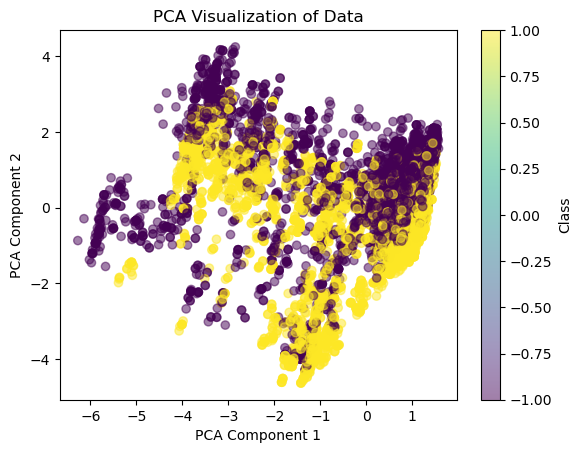

In [85]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
X_pca = pca.fit_transform(phishing_data.iloc[:, :-1])
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=phishing_data.iloc[:, -1], cmap='viridis', alpha=0.5)
plt.title("PCA Visualization of Data")
plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")
plt.colorbar(label="Class")
plt.show()


#### • Distribution Diagram of the Target Variable 'Result'

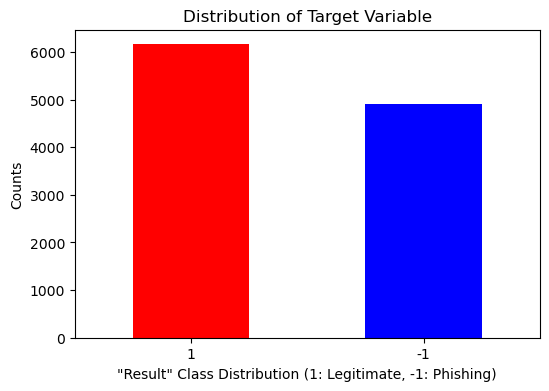

In [86]:
# Visualizing the distribution of the target variable 'Result'
plt.figure(figsize=(6, 4))
phishing_data['Result'].value_counts().plot(kind='bar', color=['red', 'blue'])
plt.title('Distribution of Target Variable')
plt.xlabel('"Result" Class Distribution (1: Legitimate, -1: Phishing)')
plt.ylabel('Counts')
plt.xticks(rotation=0)
plt.show()

#### • Checking for Missing (NaN) Values

> Although we do know that the dataset has no missing values, we proceed to double check. We will also check the existance of '?' just in case.  

In [87]:
# Checking for missing values in the data
missing_values = phishing_data.isnull().sum().sum()  # Finding the total number of missing values in the data
print(f"Number of missing values: {missing_values}")  # Printing the number of missing values
mask = phishing_data.isin(["?"])  #Creating a mask to find the rows containing '?' in the data
num_question_marks = mask.sum().sum()  #Finding the total number of rows containing '?' in the data
print(f"Number of rows containing '?': {num_question_marks}")  #Printing the number of rows containing '?'


Number of missing values: 0
Number of rows containing '?': 0


In [88]:
# Checking the data types of the columns
phishing_data.dtypes

having_IP_Address              int64
URL_Length                     int64
Shortining_Service             int64
having_At_Symbol               int64
double_slash_redirecting       int64
Prefix_Suffix                  int64
having_Sub_Domain              int64
SSLfinal_State                 int64
Domain_registeration_length    int64
Favicon                        int64
port                           int64
HTTPS_token                    int64
Request_URL                    int64
URL_of_Anchor                  int64
Links_in_tags                  int64
SFH                            int64
Submitting_to_email            int64
Abnormal_URL                   int64
Redirect                       int64
on_mouseover                   int64
RightClick                     int64
popUpWidnow                    int64
Iframe                         int64
age_of_domain                  int64
DNSRecord                      int64
web_traffic                    int64
Page_Rank                      int64
G

#### • Calculating the Feature-Value Contribution to Each Class

In [89]:
# Features to investigate. We will check the whole dataset
features_to_check = ['having_IP_Address', 'URL_Length', 'Shortining_Service', 'having_At_Symbol', 'double_slash_redirecting', 'Prefix_Suffix', 'having_Sub_Domain', 'SSLfinal_State', 'Domain_registeration_length', 'Favicon', 'port', 'HTTPS_token', 'Request_URL', 'URL_of_Anchor', 'Links_in_tags', 'SFH', 'Submitting_to_email', 'Abnormal_URL', 'Redirect', 'on_mouseover', 'RightClick', 'popUpWidnow', 'Iframe', 'age_of_domain', 'DNSRecord', 'web_traffic', 'Page_Rank', 'Google_Index', 'Links_pointing_to_page', 'Statistical_report']

# Calculating feature-value contributions to each class
for feature in features_to_check:
    print(f"\nFeature: {feature}")
    distribution = phishing_data.groupby([feature, 'Result']).size().unstack(fill_value=0)
    contribution = distribution.div(distribution.sum(axis=1), axis=0) * 100    # Converting the contribution result to percentages

    for index, row in contribution.iterrows():
        print(f"  {feature} = {index}: Class -1: {row[-1]:.2f}%, Class 1: {row[1]:.2f}%")


Feature: having_IP_Address
  having_IP_Address = -1: Class -1: 50.78%, Class 1: 49.22%
  having_IP_Address = 1: Class -1: 40.93%, Class 1: 59.07%

Feature: URL_Length
  URL_Length = -1: Class -1: 45.52%, Class 1: 54.48%
  URL_Length = 0: Class -1: 61.48%, Class 1: 38.52%
  URL_Length = 1: Class -1: 37.55%, Class 1: 62.45%

Feature: Shortining_Service
  Shortining_Service = -1: Class -1: 35.60%, Class 1: 64.40%
  Shortining_Service = 1: Class -1: 45.61%, Class 1: 54.39%

Feature: having_At_Symbol
  having_At_Symbol = -1: Class -1: 50.57%, Class 1: 49.43%
  having_At_Symbol = 1: Class -1: 43.20%, Class 1: 56.80%

Feature: double_slash_redirecting
  double_slash_redirecting = -1: Class -1: 39.33%, Class 1: 60.67%
  double_slash_redirecting = 1: Class -1: 45.04%, Class 1: 54.96%

Feature: Prefix_Suffix
  Prefix_Suffix = -1: Class -1: 51.07%, Class 1: 48.93%
  Prefix_Suffix = 1: Class -1: 0.00%, Class 1: 100.00%

Feature: having_Sub_Domain
  having_Sub_Domain = -1: Class -1: 54.59%, Class 

> Further on, we proceed to encode the categorical variables into numerical. Since, though, our data is in numerical (integer) form, we will proceed to only check that indeed the form of every column is in the correct form. 

#### • Encoding Categorical Features to Numerical Values.

In [90]:
# Separating the numerical and categorical columns
numerical_features = phishing_data.select_dtypes(include=['int64', 'float64']).columns
categorical_features = phishing_data.select_dtypes(exclude=['int64', 'float64']).columns

print(f"Numerical Features: {list(numerical_features)}")
print(f"Categorical Features: {list(categorical_features)}")

Numerical Features: ['having_IP_Address', 'URL_Length', 'Shortining_Service', 'having_At_Symbol', 'double_slash_redirecting', 'Prefix_Suffix', 'having_Sub_Domain', 'SSLfinal_State', 'Domain_registeration_length', 'Favicon', 'port', 'HTTPS_token', 'Request_URL', 'URL_of_Anchor', 'Links_in_tags', 'SFH', 'Submitting_to_email', 'Abnormal_URL', 'Redirect', 'on_mouseover', 'RightClick', 'popUpWidnow', 'Iframe', 'age_of_domain', 'DNSRecord', 'web_traffic', 'Page_Rank', 'Google_Index', 'Links_pointing_to_page', 'Statistical_report', 'Result']
Categorical Features: []


> Therefore, based on the above, we have cross checked that the data is in numerical form and no further encoding is needed. 

#### • Detailed Visualization of Data Distribution of each Feature

> The next step is the data visualization. We display the graphs regarding how the data is being distributed and how the features are related to each other.

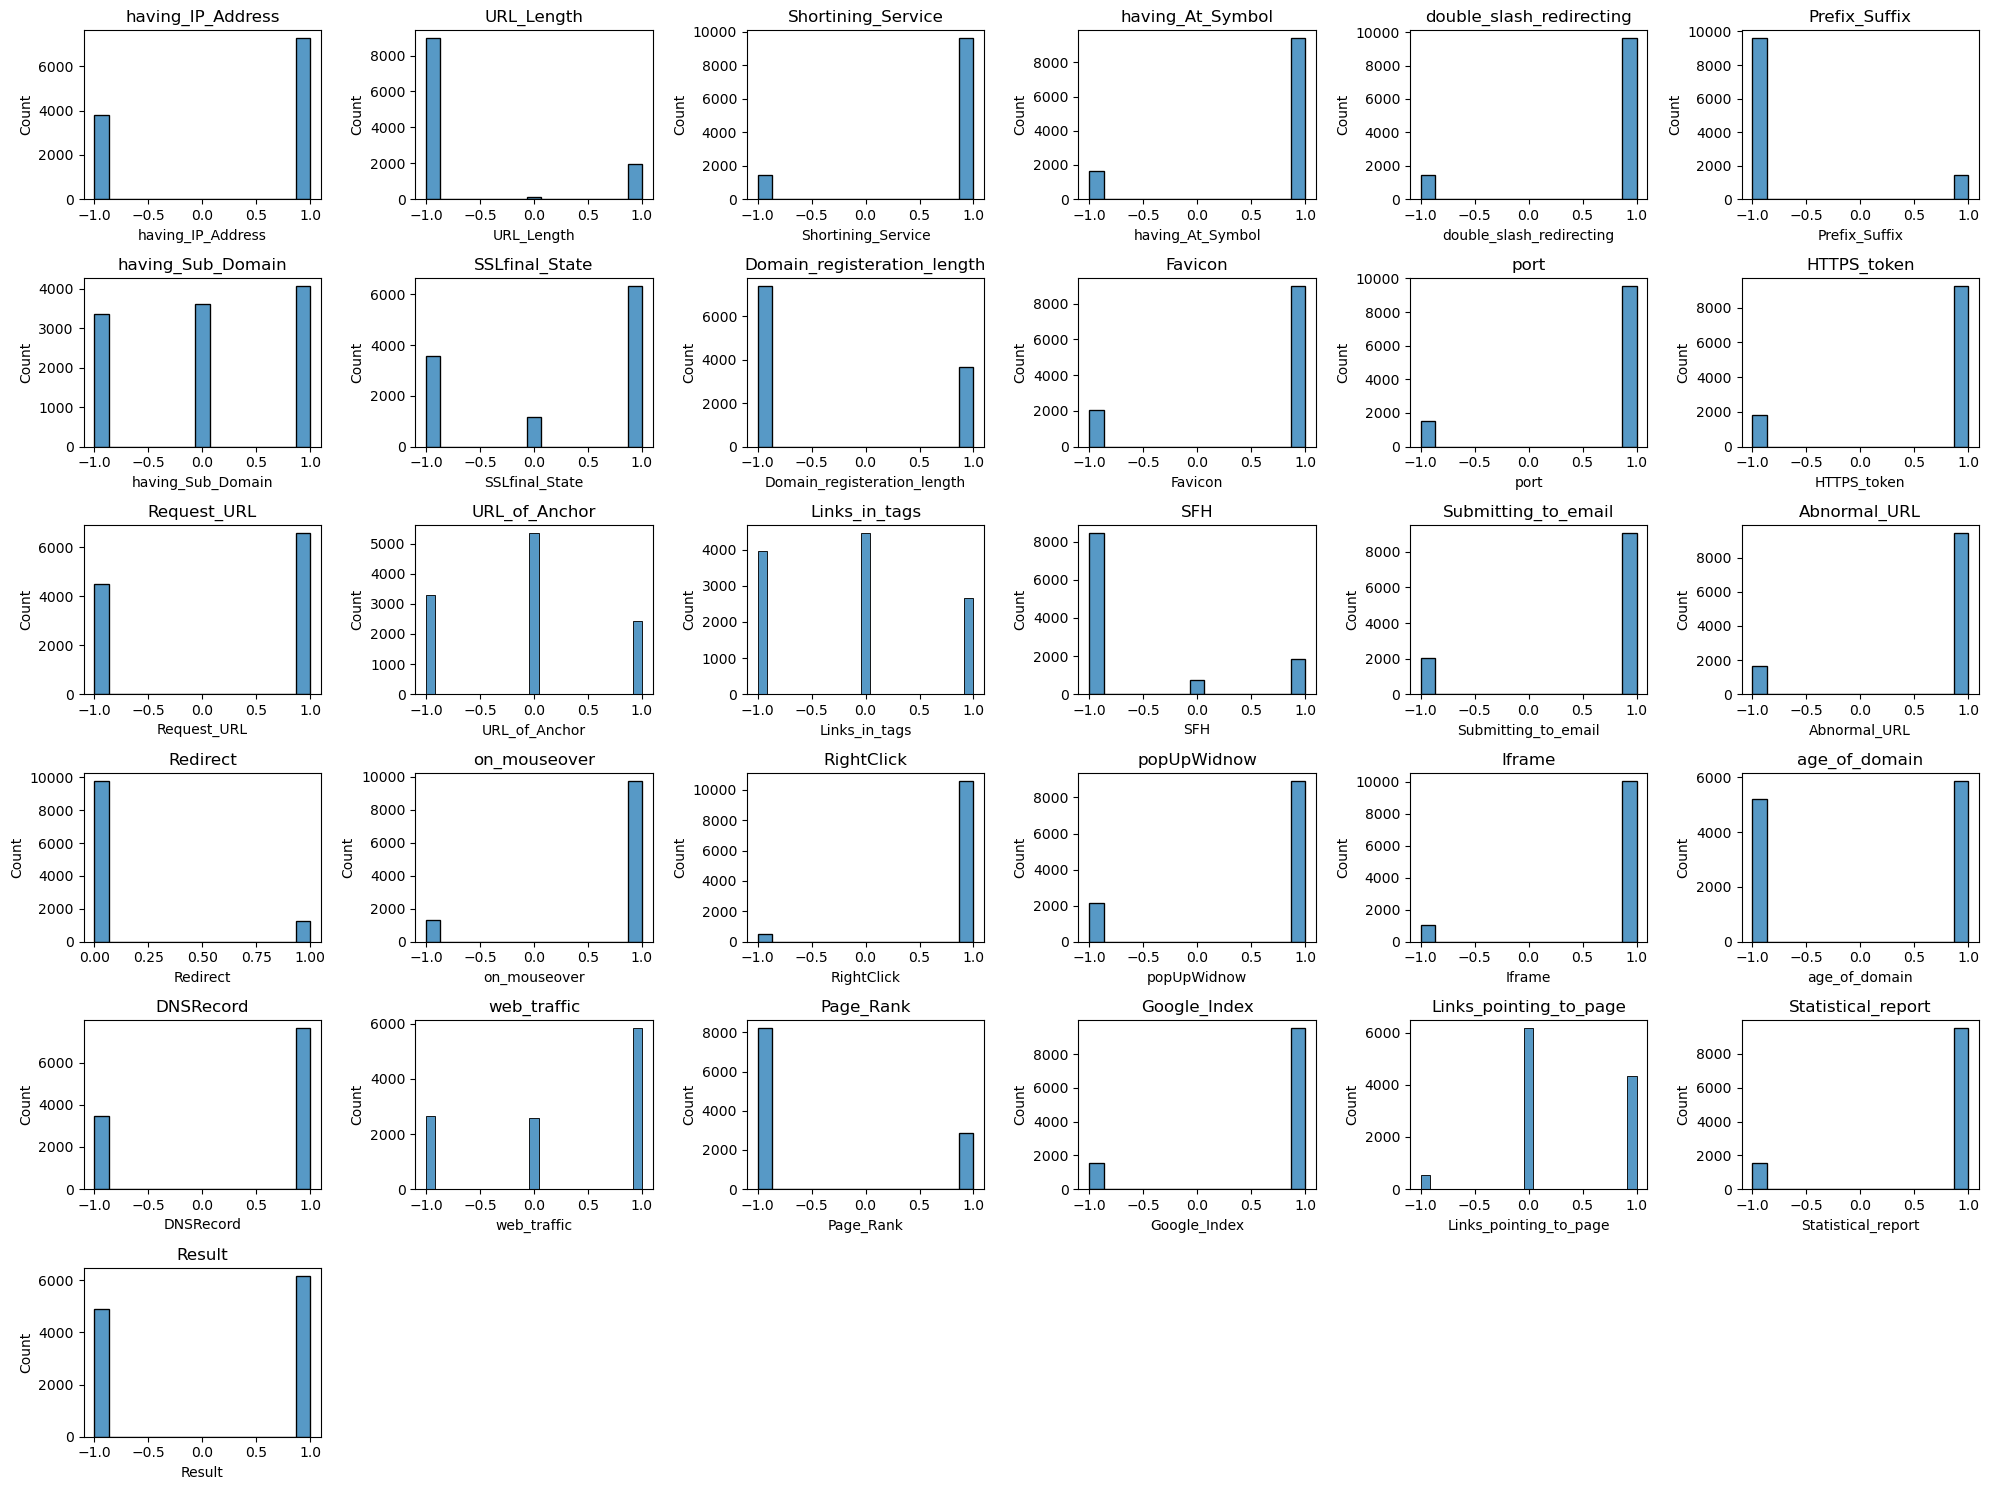

In [91]:
# Visualizing the data distribution for each feature
plt.figure(figsize=(20, 15))
for i, feature in enumerate(phishing_data.columns):
    plt.subplot(6, 6, i + 1)
    sns.histplot(phishing_data[feature])
    plt.title(feature)
plt.tight_layout()
plt.show()

> Further on, we will examine the dataset regarding the correlation between variables. By doing this, we can gain a better understanding of our data set and get a summary of it.

#### • Correlation Matrix

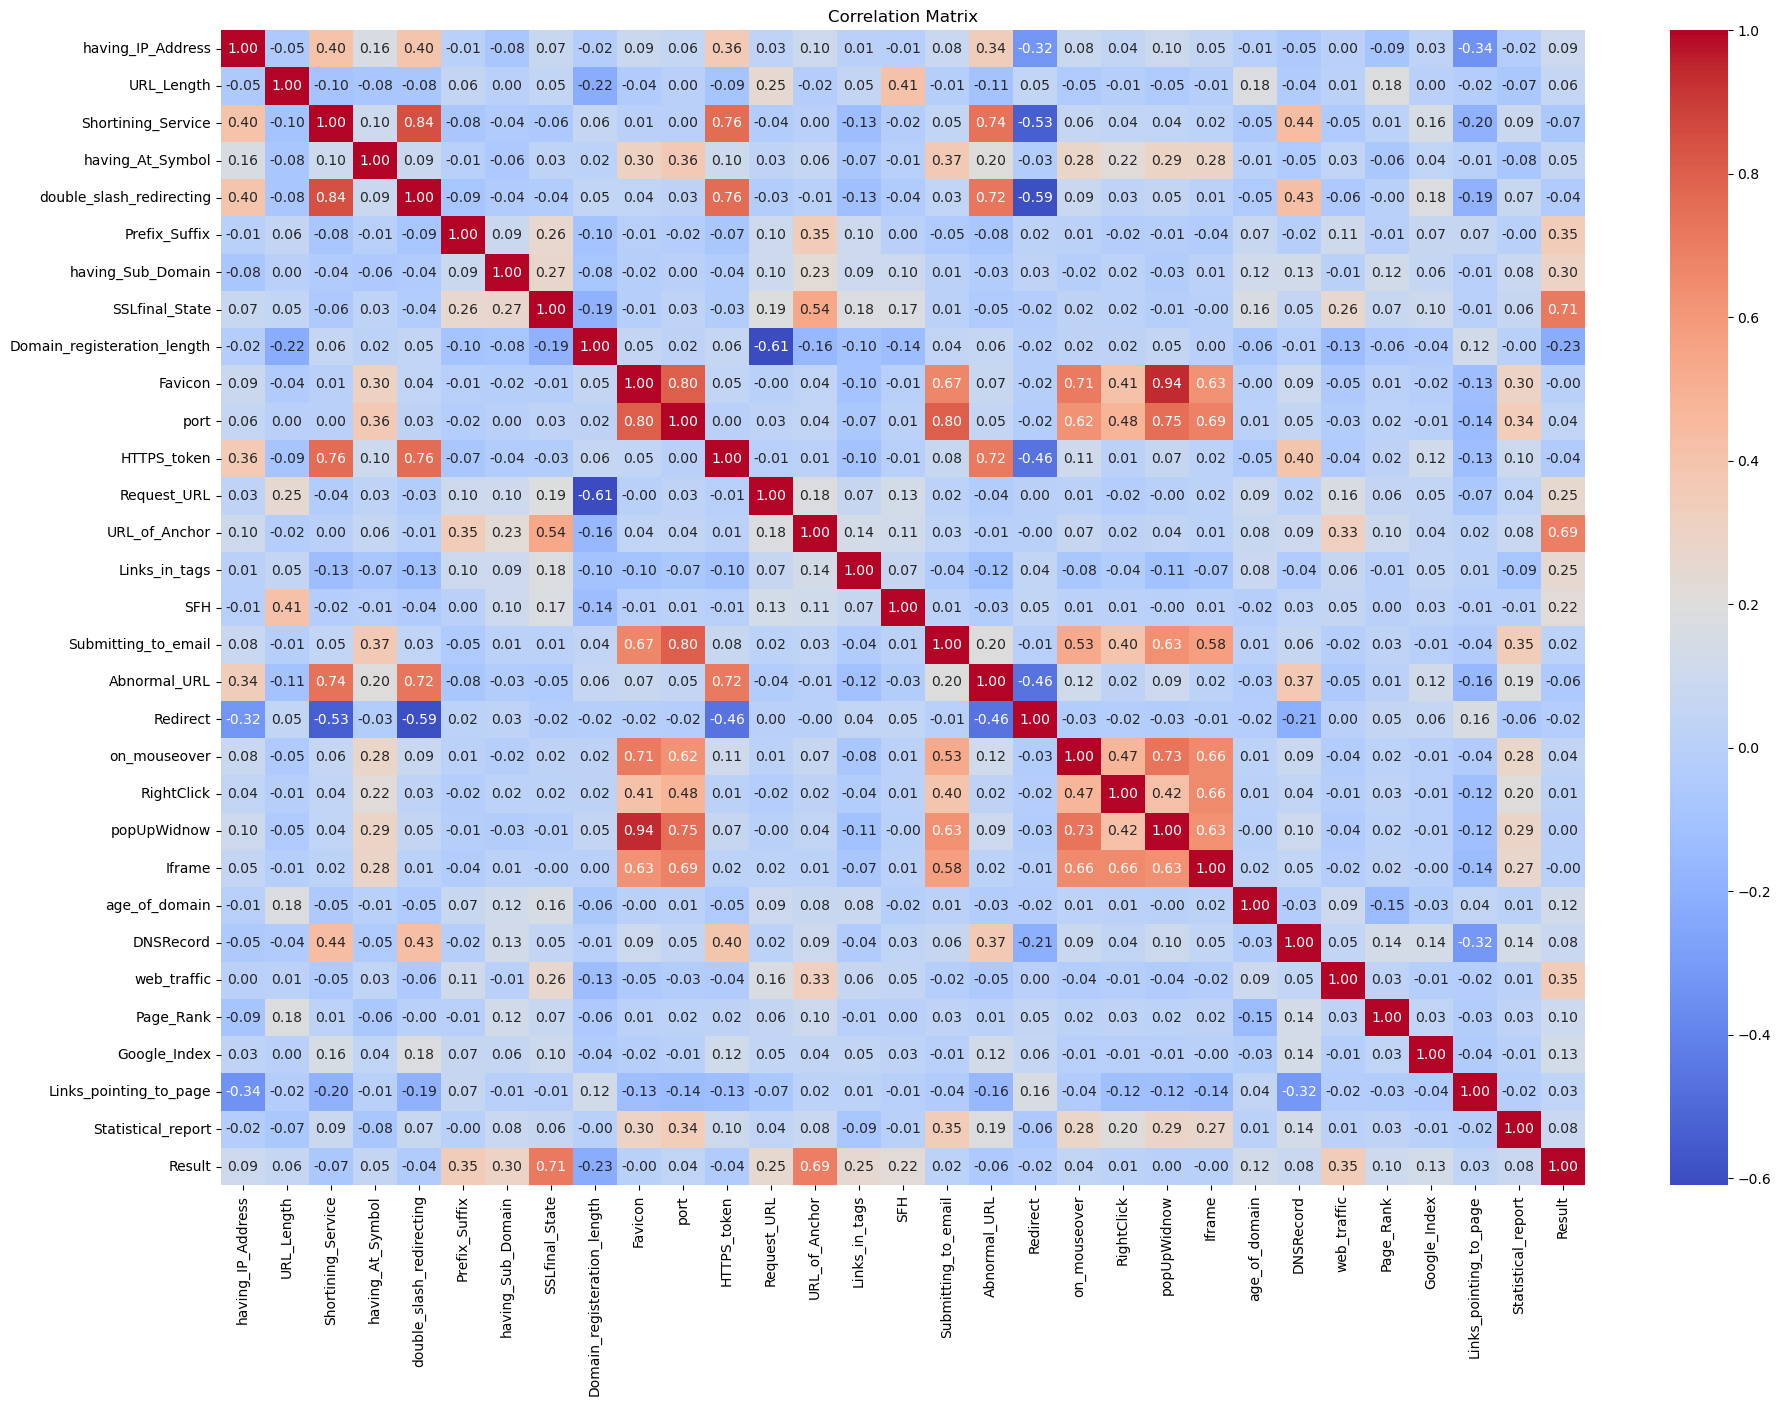

In [92]:
# Plotting the correlation matrix to check the correlation between the variables 
plt.figure(figsize=(22, 15))
correlation_matrix = phishing_data.corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix')
plt.show()

### -------- DATASET EXAMINATION BASED ON THE CORRELATION MATRIX ----------

#### In this part we will calculate the correlation between features and the target variable to select the most relevant features. 

Regarding the execution of this step, we will proceed to calculate the correlations with two ways in order to be able to understand the results we get regarding the most relevant features. First, we will calculate the correlation by the absolute value of correlation, prioritizing in the strength of the relationship between features and the target variable (regardless of the sign, whether its positive or negative). 

Correlation of features with the target variable (sorted by absolute value):

Result                         1.000000
SSLfinal_State                 0.714741
URL_of_Anchor                  0.692935
Prefix_Suffix                  0.348606
web_traffic                    0.346103
having_Sub_Domain              0.298323
Request_URL                    0.253372
Links_in_tags                  0.248229
Domain_registeration_length    0.225789
SFH                            0.221419
Google_Index                   0.128950
age_of_domain                  0.121496
Page_Rank                      0.104645
having_IP_Address              0.094160
Statistical_report             0.079857
DNSRecord                      0.075718
Shortining_Service             0.067966
Abnormal_URL                   0.060488
URL_Length                     0.057430
having_At_Symbol               0.052948
on_mouseover                   0.041838
HTTPS_token                    0.039854
double_slash_redirecting       0.038608
po

/var/folders/5q/cjb_f_41211__kk9z_2y0wzr0000gn/T/ipykernel_10456/335120156.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=sorted_correlation.index, y=sorted_correlation.values, palette='coolwarm')


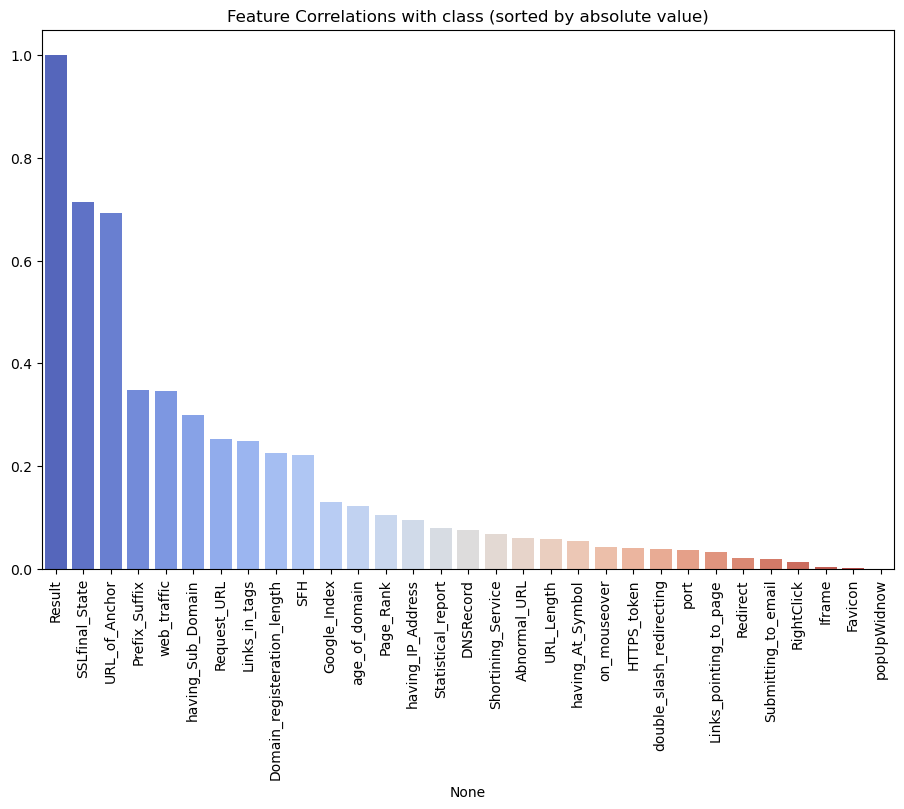

In [93]:
# Calculate the correlation matrix by the absolute value of correlation
correlation_matrix = phishing_data.corr()

# Extract correlation values between each feature and the target variable ('class')
target_correlation_absolute_val = correlation_matrix['Result']   # target classes: -1 for phishing, 1 for legitimate

# Sort features by their correlation with the target variable
sorted_correlation = target_correlation_absolute_val.abs().sort_values(ascending=False)

# Display the sorted correlations
print("Correlation of features with the target variable (sorted by absolute value):\n")
print(sorted_correlation)

# Plotting the sorted correlations based on the absolute values
plt.figure(figsize=(11, 7))
sns.barplot(x=sorted_correlation.index, y=sorted_correlation.values, palette='coolwarm')
plt.title('Feature Correlations with class (sorted by absolute value)')
plt.xticks(rotation=90)
plt.show()


Following, we will proceed to calculate the correlations based on their actual values (not their absolute ones).

In [94]:
#This part sorts the correlations by their actual values, not the absolute values

# Calculate correlations by their actual values, with the target variable ('class')
correlations_with_class = phishing_data.corr()['Result'].sort_values(ascending=False)

# Display the correlations by their actual values
print("\nCorrelations with the target variable 'Result' (actual values):\n")
print(correlations_with_class)


Correlations with the target variable 'Result' (actual values):

Result                         1.000000
SSLfinal_State                 0.714741
URL_of_Anchor                  0.692935
Prefix_Suffix                  0.348606
web_traffic                    0.346103
having_Sub_Domain              0.298323
Request_URL                    0.253372
Links_in_tags                  0.248229
SFH                            0.221419
Google_Index                   0.128950
age_of_domain                  0.121496
Page_Rank                      0.104645
having_IP_Address              0.094160
Statistical_report             0.079857
DNSRecord                      0.075718
URL_Length                     0.057430
having_At_Symbol               0.052948
on_mouseover                   0.041838
port                           0.036419
Links_pointing_to_page         0.032574
Submitting_to_email            0.018249
RightClick                     0.012653
popUpWidnow                    0.000086
Favicon       

/var/folders/5q/cjb_f_41211__kk9z_2y0wzr0000gn/T/ipykernel_10456/35828749.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=correlations_with_class.index, y=correlations_with_class.values, palette='coolwarm')


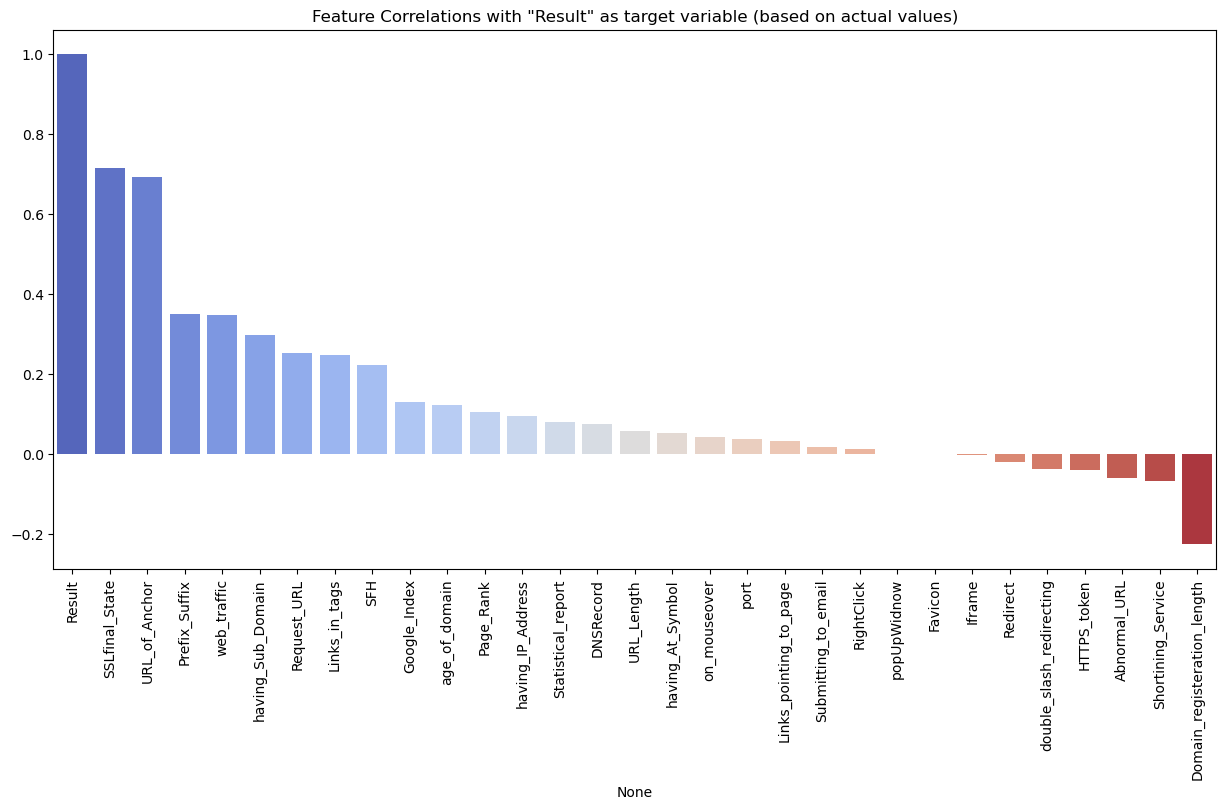

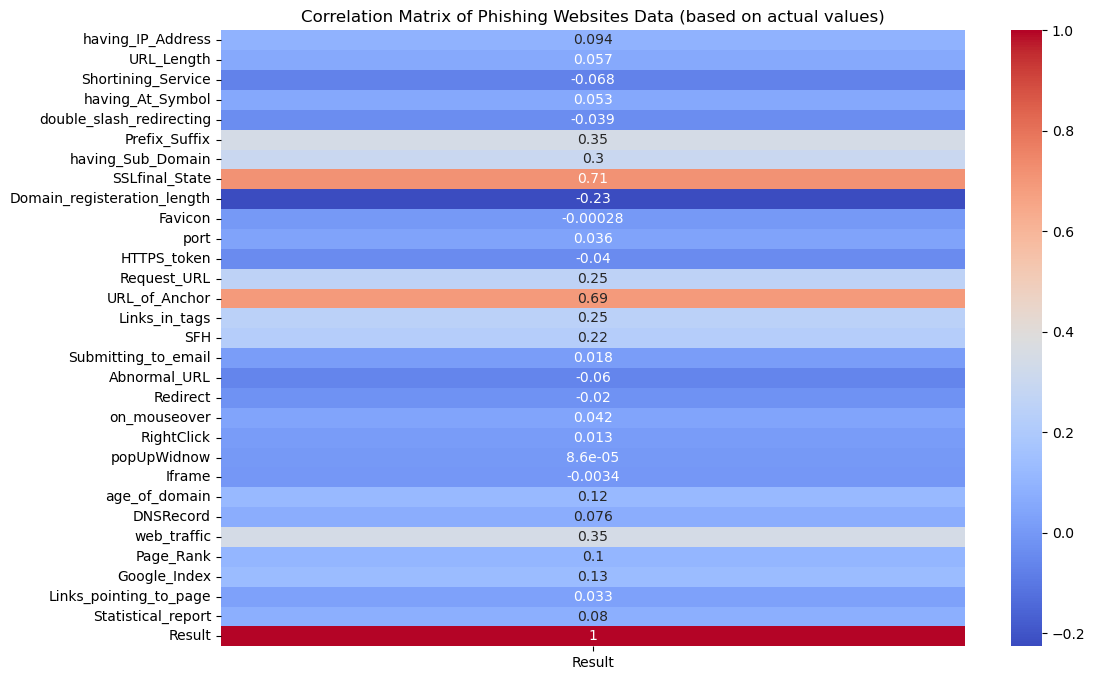

In [95]:
# Plotting the correlations based on the actual values
plt.figure(figsize=(15, 7))
sns.barplot(x=correlations_with_class.index, y=correlations_with_class.values, palette='coolwarm')
plt.title('Feature Correlations with "Result" as target variable (based on actual values)')
plt.xticks(rotation=90)
plt.show()

target_correlation = phishing_data.corr()[['Result']]
# Visualize the correlation matrix using a heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(target_correlation, annot=True, cmap='coolwarm')
plt.title('Correlation Matrix of Phishing Websites Data (based on actual values)')
plt.show()


In [96]:
#Selecting the most relevant features based on a threshold ( |correlation| > 0.2) (we set threshold greater than 0.2 in absolute value)
relevant_features = correlation_matrix['Result'][abs(correlation_matrix['Result']) > 0.2].sort_values(ascending=False)  #and sorting them in descending order

print("Relevant features:\n", relevant_features)
print("---------------------------------")
print("-> Most relevant features (with the target 'Result'):\n", relevant_features.index.to_list())
print("---------------------------------")

# Let's assume that the results we got regarding the most relevant features, are the features we will use in this examination. Therefore, we will create a new dataset with only these features, called "dataset 1".
dataset_1 = phishing_data[relevant_features.index.to_list()] # Selecting the most relevant features
dataset_1 # Displaying the data with the most relevant features

Relevant features:
 Result                         1.000000
SSLfinal_State                 0.714741
URL_of_Anchor                  0.692935
Prefix_Suffix                  0.348606
web_traffic                    0.346103
having_Sub_Domain              0.298323
Request_URL                    0.253372
Links_in_tags                  0.248229
SFH                            0.221419
Domain_registeration_length   -0.225789
Name: Result, dtype: float64
---------------------------------
-> Most relevant features (with the target 'Result'):
 ['Result', 'SSLfinal_State', 'URL_of_Anchor', 'Prefix_Suffix', 'web_traffic', 'having_Sub_Domain', 'Request_URL', 'Links_in_tags', 'SFH', 'Domain_registeration_length']
---------------------------------


,Result,SSLfinal_State,URL_of_Anchor,Prefix_Suffix,web_traffic,having_Sub_Domain,Request_URL,Links_in_tags,SFH,Domain_registeration_length
0,-1,-1,-1,-1,-1,-1,1,1,-1,-1
1,-1,1,0,-1,0,0,1,-1,-1,-1
2,-1,-1,0,-1,1,-1,1,-1,-1,-1
3,-1,-1,0,-1,1,-1,-1,0,-1,1
4,1,1,0,-1,0,1,1,0,-1,-1
...,...,...,...,...,...,...,...,...,...,...
11050,1,1,1,1,-1,1,1,1,-1,-1
11051,-1,-1,-1,-1,1,1,1,-1,0,-1
11052,-1,-1,0,-1,1,1,1,-1,-1,-1
11053,-1,-1,-1,-1,1,-1,-1,1,-1,1


All this process that we did regarding this step was to understand why we got the above results of the relevant features. Based on the correlation of features that are sorted by absolute value we can see that the threshold (correlation)> 0.2 works fine and indeed we get the most relevant features of the dataset.

**Most relevant features (with 'Result'): Result, SSLfinal_State, URL_of_Anchor, Prefix_Suffix, web_traffic, having_Sub_Domain, Request_URL, Links_in_tags, SFH, Domain_registeration_lengths**

Moving on, we will train and evaluate the new dataset with the most relevant features. For the classifiers, we will use the Logistic Regression, K-Nearest Neighbors, Decision Tree and the Random Forest Classifier. 

Regarding the evaluation part, we will get the dataset's shape, evaluate the accuracy of the particular model, get the classification report as well as the confusion matrix

In [97]:
# Splitting the data into features and target variable
X1 = dataset_1.drop('Result', axis=1)  # Features
y1 = dataset_1['Result']  # Target variable

# Split the data into training and testing sets
X1_train, X1_test, y1_train, y1_test = train_test_split(X1, y1, test_size=0.2, random_state=42)

# Standardizing the data
scaler = StandardScaler()
X1_train = scaler.fit_transform(X1_train)
X1_test = scaler.transform(X1_test)

# Defining the classifiers. We will use Logistic Regression, K-Nearest Neighbors, Decision Tree and Random Forest classifiers.
model1 = LogisticRegression(max_iter=10000, random_state=42)
model1_2 = KNeighborsClassifier(n_neighbors=5)
model1_3 = DecisionTreeClassifier(random_state=42)
model1_4 = RandomForestClassifier(random_state=42)

# Training the model
model1.fit(X1_train, y1_train)
model1_2.fit(X1_train, y1_train)
model1_3.fit(X1_train, y1_train)
model1_4.fit(X1_train, y1_train)

# Making predictions on the test set
y1_pred = model1.predict(X1_test)
y1_2_pred = model1_2.predict(X1_test)
y1_3_pred = model1_3.predict(X1_test)
y1_4_pred = model1_4.predict(X1_test)

# Printing the dataset's 1 shape 
print(f"Dataset 1 shape: {dataset_1.shape}")

Dataset 1 shape: (11055, 10)


In [98]:
# Evaluating the model. 
accuracy1 = accuracy_score(y1_test, y1_pred)
print(f"• Accuracy of the model using dataset 1 and Logistic Regression: {accuracy1:.3f}")  # Displaying the accuracy of the model using Logistic Regression
print("\nClassification Report for Logistic Regression:\n", classification_report(y1_test, y1_pred))  # Displaying the classification report for Logistic Regression
print("Confusion Matrix (Logistic Regression):\n", confusion_matrix(y1_test, y1_pred))  # Displaying the confusion matrices for Logistic Regression


accuracy1_2 = accuracy_score(y1_test, y1_2_pred)
print(f"\n• Accuracy of the model using dataset 1 and K-Nearest Neighbors: {accuracy1_2:.3f}")  # Displaying the accuracy of the model using K-Nearest Neighbors
print("\nClassification Report for K-Nearest Neighbors:\n", classification_report(y1_test, y1_2_pred))   # Displaying the classification report for K-Nearest Neighbors
print("Confusion Matrix (K-Nearest Neighbors):\n", confusion_matrix(y1_test, y1_2_pred))   # Displaying the confusion matrices for K-Nearest Neighbors


accuracy1_3 = accuracy_score(y1_test, y1_3_pred)
print(f"\n• Accuracy of the model using dataset 1 and Decision Tree: {accuracy1_3:.3f}")
print("\nClassification Report for Decision Tree:", classification_report(y1_test, y1_3_pred)) # Displaying the classification report for Decision Tree
print("Confusion Matrix (Decision Tree):\n", confusion_matrix(y1_test, y1_3_pred))  # Displaying the confusion matrices for Decision Tree


accuracy1_4 = accuracy_score(y1_test, y1_4_pred)
print(f"\n• Accuracy of the model using dataset 1 and Random Forest: {accuracy1_4:.3f}")
print("\nClassification Report for Random Forest:", classification_report(y1_test, y1_4_pred))  # Displaying the classification report for Random Forest
print("Confusion Matrix (Random Forest):\n", confusion_matrix(y1_test, y1_4_pred))  # Displaying the confusion matrices for Random Forest


• Accuracy of the model using dataset 1 and Logistic Regression: 0.919

Classification Report for Logistic Regression:
               precision    recall  f1-score   support

          -1       0.92      0.90      0.91       956
           1       0.92      0.94      0.93      1255

    accuracy                           0.92      2211
   macro avg       0.92      0.92      0.92      2211
weighted avg       0.92      0.92      0.92      2211

Confusion Matrix (Logistic Regression):
 [[ 856  100]
 [  79 1176]]

• Accuracy of the model using dataset 1 and K-Nearest Neighbors: 0.928

Classification Report for K-Nearest Neighbors:
               precision    recall  f1-score   support

          -1       0.93      0.90      0.91       956
           1       0.92      0.95      0.94      1255

    accuracy                           0.93      2211
   macro avg       0.93      0.92      0.93      2211
weighted avg       0.93      0.93      0.93      2211

Confusion Matrix (K-Nearest Neighbors

#### - Comparison of the Different Model Performance Metrics for Dataset 1 -

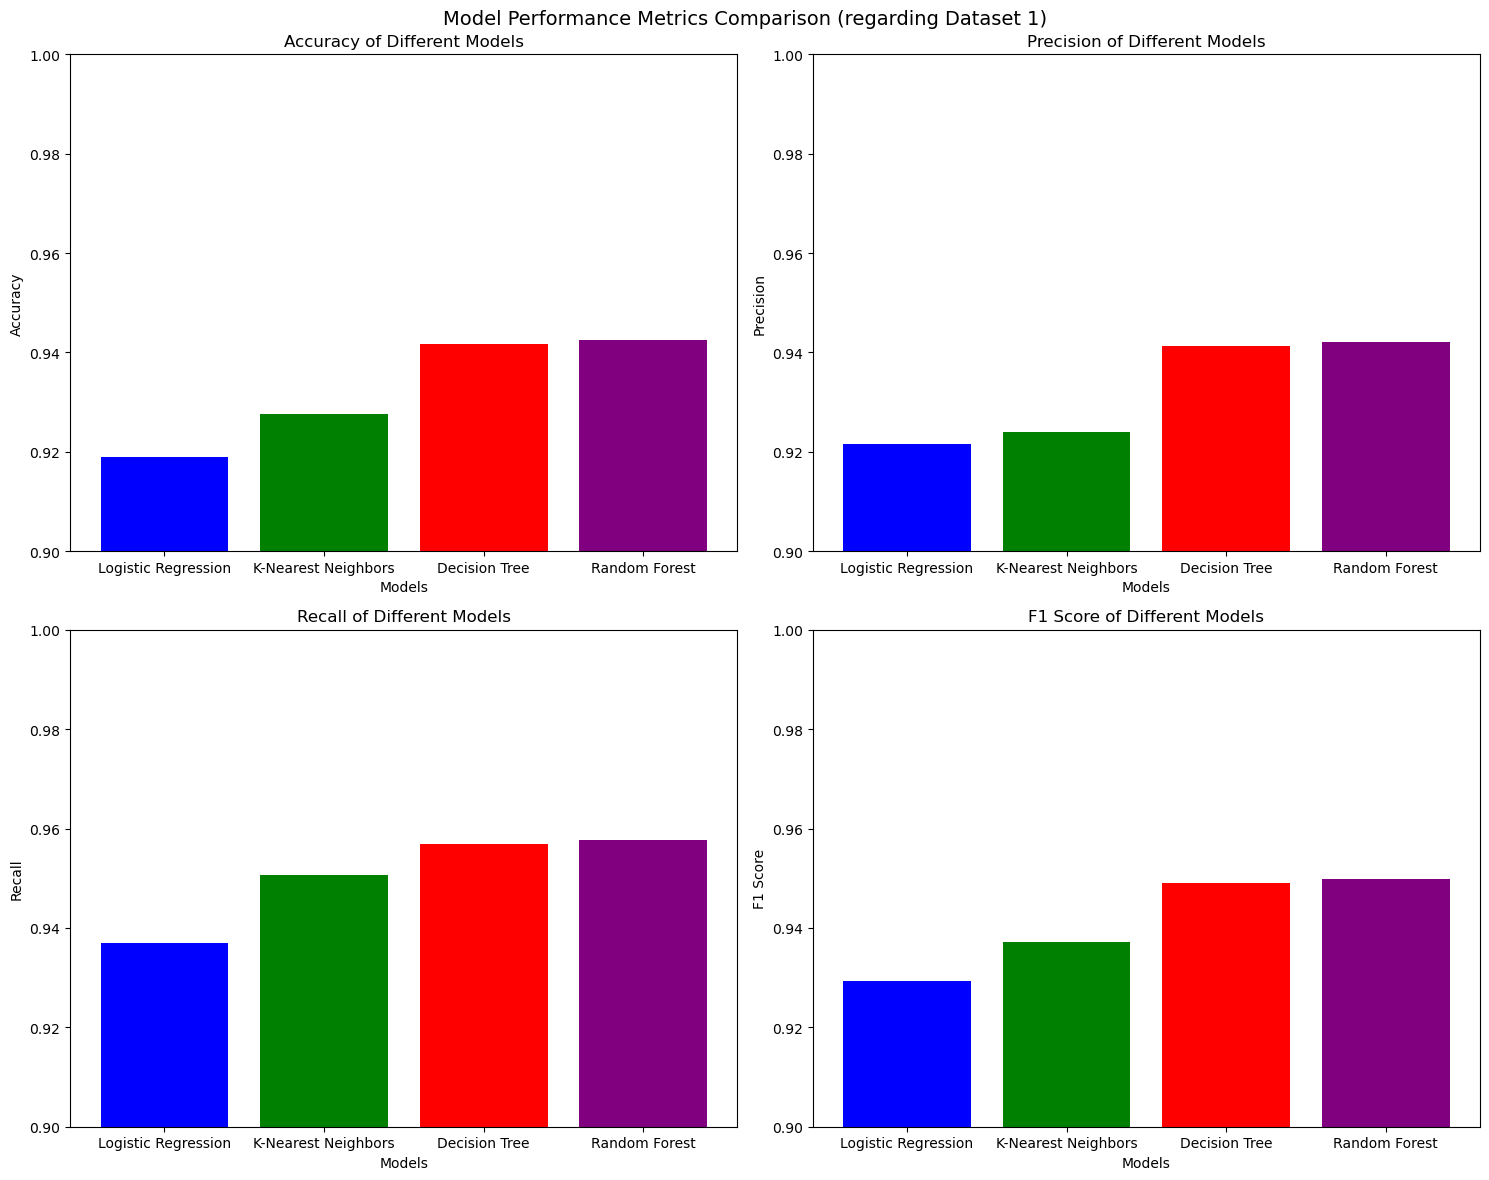

In [99]:
# Accuracy values for each model
accuracy_values = [accuracy1, accuracy1_2, accuracy1_3, accuracy1_4]
model_names = ['Logistic Regression', 'K-Nearest Neighbors', 'Decision Tree', 'Random Forest']

# Precision, Recall and F1 Score for each model

# Logistic Regression
precision1 = precision_score(y1_test, y1_pred)
recall1 = recall_score(y1_test, y1_pred)
f1_score1 = f1_score(y1_test, y1_pred)

# K-Nearest Neighbors
precision1_2 = precision_score(y1_test, y1_2_pred)
recall1_2 = recall_score(y1_test, y1_2_pred)
f1_score1_2 = f1_score(y1_test, y1_2_pred)

# Decision Tree
precision1_3 = precision_score(y1_test, y1_3_pred)
recall1_3 = recall_score(y1_test, y1_3_pred)
f1_score1_3 = f1_score(y1_test, y1_3_pred)

# Random Forest
precision1_4 = precision_score(y1_test, y1_4_pred)
recall1_4 = recall_score(y1_test, y1_4_pred)
f1_score1_4 = f1_score(y1_test, y1_4_pred)

# Plotting the metrics in subplots
fig, axs = plt.subplots(2, 2, figsize=(15, 12))
fig.suptitle('Model Performance Metrics Comparison (regarding Dataset 1)', fontsize=14)

# Accuracy subplot
axs[0, 0].bar(model_names, accuracy_values, color=['blue', 'green', 'red', 'purple'])
axs[0, 0].set_xlabel('Models')
axs[0, 0].set_ylabel('Accuracy')
axs[0, 0].set_title('Accuracy of Different Models')
axs[0, 0].set_ylim(0.9, 1.0)  # Setting the y-axis limit for better visualization

# Precision subplot
axs[0, 1].bar(model_names, [precision1, precision1_2, precision1_3, precision1_4], color=['blue', 'green', 'red', 'purple'])
axs[0, 1].set_xlabel('Models')
axs[0, 1].set_ylabel('Precision')
axs[0, 1].set_title('Precision of Different Models')
axs[0, 1].set_ylim(0.9, 1.0)  # Setting the y-axis limit for better visualization

# Recall subplot
axs[1, 0].bar(model_names, [recall1, recall1_2, recall1_3, recall1_4], color=['blue', 'green', 'red', 'purple'])
axs[1, 0].set_xlabel('Models')
axs[1, 0].set_ylabel('Recall')
axs[1, 0].set_title('Recall of Different Models')
axs[1, 0].set_ylim(0.9, 1.0)  # Setting the y-axis limit for better visualization

# F1 Score subplot
axs[1, 1].bar(model_names, [f1_score1, f1_score1_2, f1_score1_3, f1_score1_4], color=['blue', 'green', 'red', 'purple'])
axs[1, 1].set_xlabel('Models')
axs[1, 1].set_ylabel('F1 Score')
axs[1, 1].set_title('F1 Score of Different Models')
axs[1, 1].set_ylim(0.9, 1.0)  # Setting the y-axis limit for better visualization

plt.tight_layout()
plt.show()



#### ----- Examining the data with the use of different feature selectors -----

Following, in our main dataset, we will apply the **Sequential Feature Selector (SFS)** to select the best subset of features for classification. This subset will be the dataset 2. 

Regarding the evaluation part, we will get the dataset's shape, evaluate the accuracy of the particular model, get the classification report as well as the confusion matrix

#### • **Sequential Feature Selector (SFS)**

For the classifiers, we will use the following:  

- Logistic Regression
- K-Nearest Neighbors (KNN)
- Decision Tree
- Random Forest

In [100]:
#Splitting the data into features and target variable
X2 = phishing_data.drop('Result', axis=1)   # Features
y2 = phishing_data['Result']   # Target variable

# Split the data into training and testing sets
X2_train, X2_test, y2_train, y2_test = train_test_split(X2, y2, test_size=0.2, random_state=42)

#Defining the classifier. We will use the Logistic Regression model
model2 = LogisticRegression(max_iter=10000, random_state=42)

# Applying Sequential Feature Selector (SFS)
sfs = SequentialFeatureSelector(model2, n_features_to_select=9, direction='forward', scoring='accuracy', cv=5)

# Fitting the model with the Sequential Feature Selector
sfs = sfs.fit(X2_train, y2_train)

# Getting the selected features
selected_features = X2_train.columns[sfs.get_support()].tolist()  # Getting the selected features
print(f"Selected Features with SFS: {selected_features + ['Result']}")  #Printing the selected features

# Creating dataset 2 with the selected features
dataset_2 = phishing_data[selected_features + ['Result']]

# Printing the dataset's 2 shape 
print(f"\nDataset 2 shape: {dataset_2.shape}")

# Train and evaluating the selected features using multiple classifiers
# We will use Logistic Regression, K-Nearest Neighbors, Decision Tree and Random Forest classifiers.

# Logistic Regression
X_train_sfs = sfs.transform(X2_train)  
X_test_sfs = sfs.transform(X2_test)
model_sfs = LogisticRegression(max_iter=10000)
model_sfs.fit(X_train_sfs, y2_train)
y_pred_sfs = model_sfs.predict(X_test_sfs)
accuracy_sfs = accuracy_score(y2_test, y_pred_sfs)
print(f"\n•Accuracy of the model using SFS-selected features and Logistic Regression: {accuracy_sfs:.3f}")
print("Classification Report for Logistic Regression:\n", classification_report(y2_test, y_pred_sfs))
print("\nConfusion Matrix (Logistic Regression):\n", confusion_matrix(y2_test, y_pred_sfs))

# K-Nearest Neighbors
model_sf_1 = KNeighborsClassifier(n_neighbors=5)
model_sf_1.fit(X_train_sfs, y2_train)
y_pred_sfs_1 = model_sf_1.predict(X_test_sfs)
accuracy_sfs_1 = accuracy_score(y2_test, y_pred_sfs_1)
print(f"\n•Accuracy of the model using SFS-selected features and K-Nearest Neighbors: {accuracy_sfs_1:.3f}")
print("Classification Report for Logistic Regression:\n", classification_report(y2_test, y_pred_sfs_1))
print("\nConfusion Matrix (K-Nearest Neighbors):\n", confusion_matrix(y2_test, y_pred_sfs_1))

# Decision Tree
model_sf_2 = DecisionTreeClassifier(random_state=42)
model_sf_2.fit(X_train_sfs, y2_train)
y_pred_sf_2 = model_sf_2.predict(X_test_sfs)
accuracy_sf_2 = accuracy_score(y2_test, y_pred_sf_2)
print(f"\n•Accuracy of the model using SFS-selected features and Decision Tree: {accuracy_sf_2:.3f}")
print("Classification Report for Logistic Regression:\n", classification_report(y2_test, y_pred_sf_2))
print("\nConfusion Matrix (Decision Tree):\n", confusion_matrix(y2_test, y_pred_sf_2))

# Random Forest
model_sf_3 = RandomForestClassifier(random_state=42)
model_sf_3.fit(X_train_sfs, y2_train)
y_pred_sf_3 = model_sf_3.predict(X_test_sfs)
accuracy_sf_3 = accuracy_score(y2_test, y_pred_sf_3)
print(f"\n•Accuracy of the model using SFS-selected features and Random Forest: {accuracy_sf_3:.3f}")
print("Classification Report for Logistic Regression:\n", classification_report(y2_test, y_pred_sf_3))
print("\nConfusion Matrix (Random Forest):\n", confusion_matrix(y2_test, y_pred_sf_3))

Selected Features with SFS: ['having_IP_Address', 'URL_Length', 'having_At_Symbol', 'Prefix_Suffix', 'SSLfinal_State', 'port', 'URL_of_Anchor', 'Submitting_to_email', 'Statistical_report', 'Result']

Dataset 2 shape: (11055, 10)

•Accuracy of the model using SFS-selected features and Logistic Regression: 0.923
Classification Report for Logistic Regression:
               precision    recall  f1-score   support

          -1       0.93      0.88      0.91       956
           1       0.92      0.95      0.93      1255

    accuracy                           0.92      2211
   macro avg       0.92      0.92      0.92      2211
weighted avg       0.92      0.92      0.92      2211


Confusion Matrix (Logistic Regression):
 [[ 845  111]
 [  59 1196]]

•Accuracy of the model using SFS-selected features and K-Nearest Neighbors: 0.926
Classification Report for Logistic Regression:
               precision    recall  f1-score   support

          -1       0.94      0.89      0.91       956
    

#### - Comparison of the Different Model Performance Metrics for Dataset 2 (SFS) -

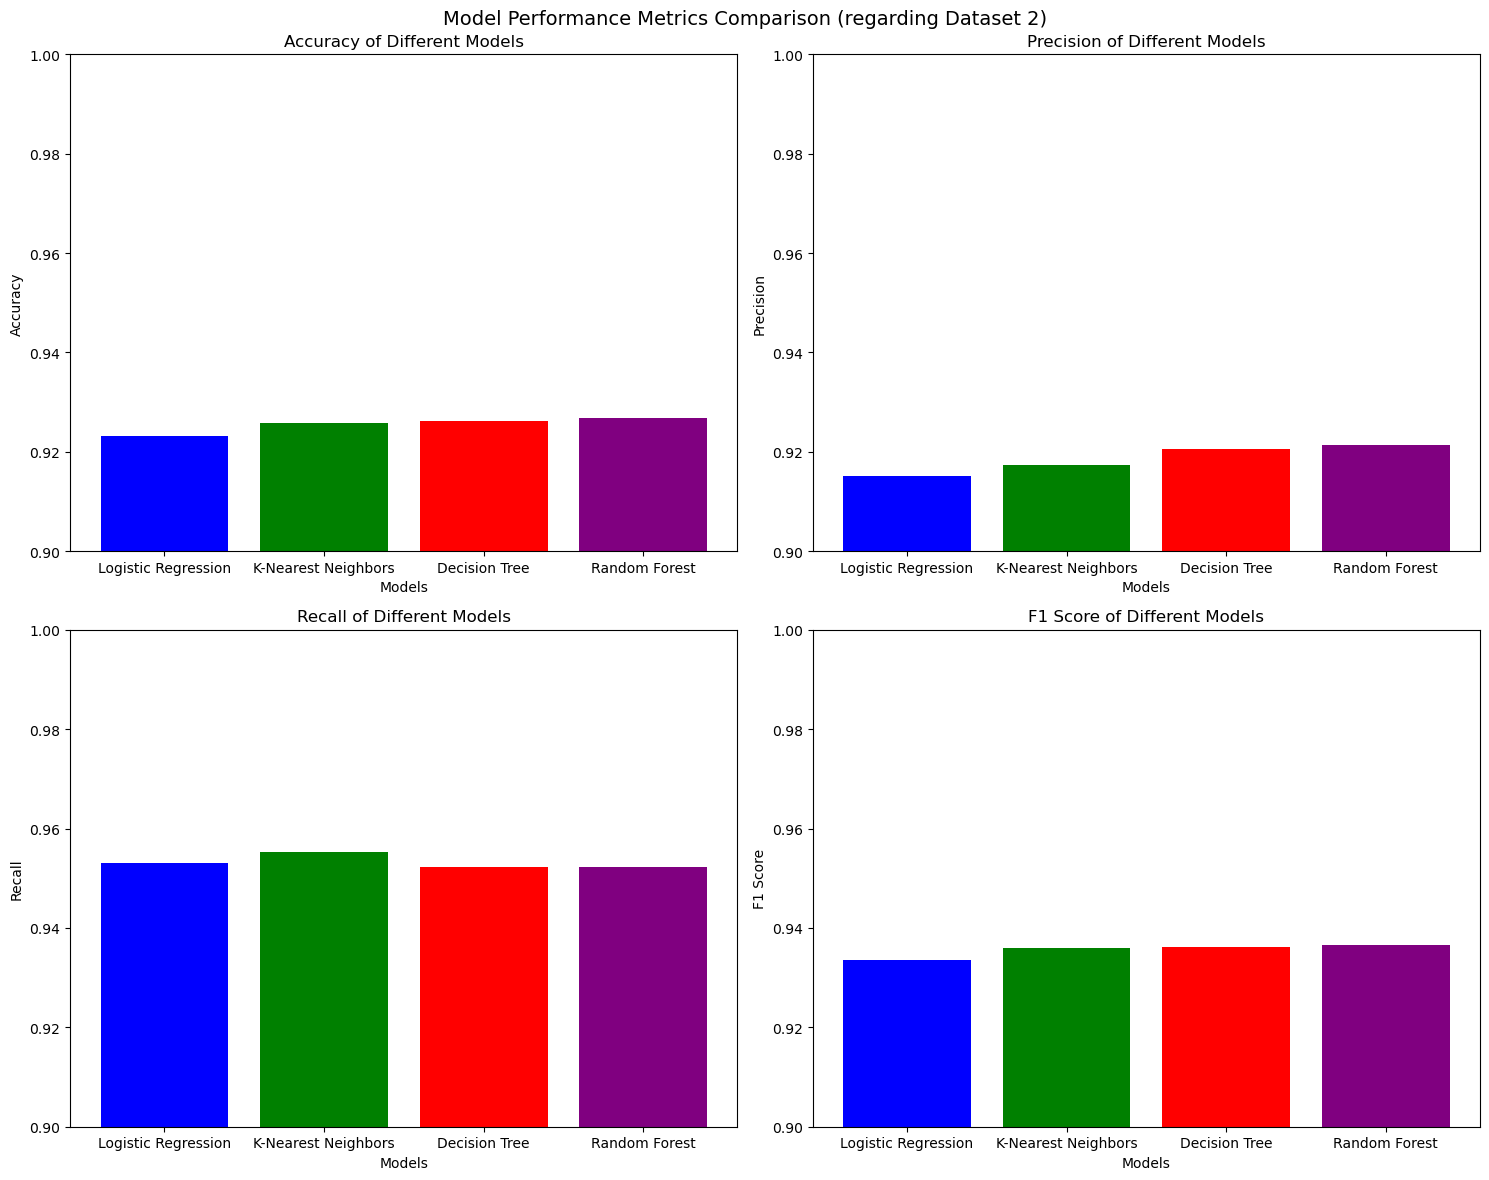

In [101]:
# Accuracy values for each model
accuracy_values_sfs = [accuracy_sfs, accuracy_sfs_1, accuracy_sf_2, accuracy_sf_3]
model_names_sfs = ['Logistic Regression', 'K-Nearest Neighbors', 'Decision Tree', 'Random Forest']

# Precision, Recall, and F1-Score for each model

# Logistic Regression
precision_sfs = precision_score(y2_test, y_pred_sfs)
recall_sfs = recall_score(y2_test, y_pred_sfs)
f1_score_sfs = f1_score(y2_test, y_pred_sfs)

# K-Nearest Neighbors
precision_sfs_1 = precision_score(y2_test, y_pred_sfs_1)
recall_sfs_1 = recall_score(y2_test, y_pred_sfs_1)
f1_score_sfs_1 = f1_score(y2_test, y_pred_sfs_1)

# Decision Tree
precision_sf_2 = precision_score(y2_test, y_pred_sf_2)
recall_sf_2 = recall_score(y2_test, y_pred_sf_2)
f1_score_sf_2 = f1_score(y2_test, y_pred_sf_2)

# Random Forest
precision_sf_3 = precision_score(y2_test, y_pred_sf_3)
recall_sf_3 = recall_score(y2_test, y_pred_sf_3)
f1_score_sf_3 = f1_score(y2_test, y_pred_sf_3)

precision_values_sfs = [precision_sfs, precision_sfs_1, precision_sf_2, precision_sf_3]
recall_values_sfs = [recall_sfs, recall_sfs_1, recall_sf_2, recall_sf_3]
f1_score_values_sfs = [f1_score_sfs, f1_score_sfs_1, f1_score_sf_2, f1_score_sf_3]


# Plotting the metrics in subplots
fig, axs = plt.subplots(2, 2, figsize=(15, 12))
fig.suptitle('Model Performance Metrics Comparison (regarding Dataset 2)', fontsize=14)

# Accuracy subplot
axs[0, 0].bar(model_names_sfs, accuracy_values_sfs, color=['blue', 'green', 'red', 'purple'])
axs[0, 0].set_xlabel('Models')
axs[0, 0].set_ylabel('Accuracy')
axs[0, 0].set_title('Accuracy of Different Models')
axs[0, 0].set_ylim(0.9, 1.0)  # Setting the y-axis limit for better visualization

# Precision subplot
axs[0, 1].bar(model_names_sfs, precision_values_sfs, color=['blue', 'green', 'red', 'purple'])
axs[0, 1].set_xlabel('Models')
axs[0, 1].set_ylabel('Precision')
axs[0, 1].set_title('Precision of Different Models')
axs[0, 1].set_ylim(0.9, 1.0)  # Setting the y-axis limit for better visualization

# Recall subplot
axs[1, 0].bar(model_names_sfs, recall_values_sfs, color=['blue', 'green', 'red', 'purple'])
axs[1, 0].set_xlabel('Models')
axs[1, 0].set_ylabel('Recall')
axs[1, 0].set_title('Recall of Different Models')
axs[1, 0].set_ylim(0.9, 1.0)  # Setting the y-axis limit for better visualization

# F1 Score subplot
axs[1, 1].bar(model_names_sfs, f1_score_values_sfs, color=['blue', 'green', 'red', 'purple'])
axs[1, 1].set_xlabel('Models')
axs[1, 1].set_ylabel('F1 Score')
axs[1, 1].set_title('F1 Score of Different Models')
axs[1, 1].set_ylim(0.9, 1.0)  # Setting the y-axis limit for better visualization

plt.tight_layout()
plt.show()


The **Sequential Feature Selector (SFS)** identified the following key features that contribute the most to predicting phishing websites (we also included in the list the target column 'Result'):

- Selected Features with SFS: ['having_IP_Address', 'URL_Length', 'having_At_Symbol', 'Prefix_Suffix', 'SSLfinal_State', 'port', 'URL_of_Anchor', 'Submitting_to_email', 'Statistical_report', 'Result']


By using only these 9 features, we reduced the dimensionality of the dataset while maintaining strong predictive capabilities. The new dataset (Dataset 2) retains these features along with the target variable, significantly simplifying the analysis.

To validate the robustness of our feature selection process, we proceed now to evaluate the models using **k-fold cross-validation**. Cross-validation helps ensure that the performance of each model generalizes well to unseen data by splitting the dataset into multiple train-test splits. This approach minimizes the risk of overfitting and provides a more reliable estimate of model performance.

### **Cross Validation** 

We will perform 5-fold cross-validation on the selected features using the following classifiers:
- Logistic Regression
- K-Nearest Neighbors (KNN)
- Decision Tree
- Random Forest

In [102]:
# To store cross-validation results
cv_results = {}

# Defining all of the models we've used to evaluate
models = {
    'Logistic Regression': LogisticRegression(max_iter=10000, random_state=42),
    'K-Nearest Neighbors': KNeighborsClassifier(n_neighbors=5),
    'Decision Tree': DecisionTreeClassifier(random_state=42),
    'Random Forest': RandomForestClassifier(random_state=42)
}

print("The mean accuracy and standard deviation for each model:\n")
# Perform 5-fold cross-validation
for model_name, model in models.items():
    scores = cross_val_score(model, X2_train, y2_train, cv=5, scoring='accuracy')  # We are performing 5-fold cross-validation
    cv_results[model_name] = scores
    print(f"{model_name} Cross-Validation Accuracy: {scores.mean():.2f} ± {scores.std():.2f}")

# Printing all cross-validation results
print("\nCross-Validation Results Summary:")
for model_name, scores in cv_results.items():
    print(f"{model_name}: {scores}")

print("\nThe above summary results contain the accuracy scores of each model across the 5 folds used during the cross-validation process.")

The mean accuracy and standard deviation for each model:

Logistic Regression Cross-Validation Accuracy: 0.93 ± 0.01
K-Nearest Neighbors Cross-Validation Accuracy: 0.94 ± 0.01
Decision Tree Cross-Validation Accuracy: 0.96 ± 0.00
Random Forest Cross-Validation Accuracy: 0.97 ± 0.00

Cross-Validation Results Summary:
Logistic Regression: [0.92481628 0.92198982 0.92594686 0.93329565 0.93608597]
K-Nearest Neighbors: [0.92877332 0.93046919 0.94460147 0.94629734 0.94117647]
Decision Tree: [0.96495195 0.96438666 0.96212549 0.96438666 0.96266968]
Random Forest: [0.96890899 0.97060486 0.97003957 0.97060486 0.9688914 ]

The above summary results contain the accuracy scores of each model across the 5 folds used during the cross-validation process.


### • **Recursive Feature Elimination (RFE)**
We will perform the Recursive Feature Elimination (RFE) on the selected features using the following classifiers:
- Logistic Regression
- Decision Tree
- Random Forest

> This subset will be dataset 3. 

In [103]:
# Defining the models we will use. The K-Nearest Neighbors model cannot be used with RFE, so we will exclude it.
models = {
    'Logistic Regression': LogisticRegression(max_iter=10000, random_state=42),
    'Decision Tree': DecisionTreeClassifier(random_state=42),
    'Random Forest': RandomForestClassifier(random_state=42)
}

# Scalling the data
scaler = StandardScaler()
X2_train_scaled = scaler.fit_transform(X2_train)
X2_test_scaled = scaler.transform(X2_test)

# Defining the dictionaries to store the performance metrics for the comparison that we will implement later on 
accuracy_rfe = {}
precision_rfe = {}
recall_rfe = {}
f1_score_rfe = {}

# Applying RFE and evaluate each model
for model_name, model_rfe in models.items():
    rfe = RFE(estimator=model_rfe, n_features_to_select=9)
    rfe.fit(X2_train_scaled, y2_train)
    selected_features_rfe = X2_train.columns[rfe.support_].tolist()
    print(f"• Selected Features with RFE using {model_name}: {selected_features_rfe + ['Result']}")

    # Transform training and testing data
    X_train_rfe = rfe.transform(X2_train_scaled)
    X_test_rfe = rfe.transform(X2_test_scaled)

    # Train and predict
    model_rfe.fit(X_train_rfe, y2_train)
    y_pred_rfe = model_rfe.predict(X_test_rfe)

    # Storing the performance metrics
    accuracy_rfe[model_name] = accuracy_score(y2_test, y_pred_rfe)
    precision_rfe[model_name] = precision_score(y2_test, y_pred_rfe)
    recall_rfe[model_name] = recall_score(y2_test, y_pred_rfe)
    f1_score_rfe[model_name] = f1_score(y2_test, y_pred_rfe)

    # Display the metrics
    print(f"\nAccuracy of the model using RFE-selected features with {model_name}: {accuracy_rfe[model_name]:.3f}")
    print(f"\nClassification Report for RFE using {model_name}:\n", classification_report(y2_test, y_pred_rfe))
    print(f"Confusion Matrix (RFE using {model_name}):\n", confusion_matrix(y2_test, y_pred_rfe))
    print("\n")

# Converting the metrics to lists for plotting them later on
model_names = list(models.keys())
accuracy_values = [accuracy_rfe[model] for model in model_names]
precision_values = [precision_rfe[model] for model in model_names]
recall_values = [recall_rfe[model] for model in model_names]
f1_score_values = [f1_score_rfe[model] for model in model_names]

• Selected Features with RFE using Logistic Regression: ['having_IP_Address', 'Prefix_Suffix', 'having_Sub_Domain', 'SSLfinal_State', 'URL_of_Anchor', 'Links_in_tags', 'SFH', 'web_traffic', 'Google_Index', 'Result']

Accuracy of the model using RFE-selected features with Logistic Regression: 0.917

Classification Report for RFE using Logistic Regression:
               precision    recall  f1-score   support

          -1       0.91      0.90      0.90       956
           1       0.92      0.93      0.93      1255

    accuracy                           0.92      2211
   macro avg       0.92      0.92      0.92      2211
weighted avg       0.92      0.92      0.92      2211

Confusion Matrix (RFE using Logistic Regression):
 [[ 859   97]
 [  86 1169]]


• Selected Features with RFE using Decision Tree: ['Prefix_Suffix', 'having_Sub_Domain', 'SSLfinal_State', 'Request_URL', 'URL_of_Anchor', 'Links_in_tags', 'age_of_domain', 'web_traffic', 'Links_pointing_to_page', 'Result']

Accuracy o

#### - Comparison of the Different Model Performance Metrics (RFE) -

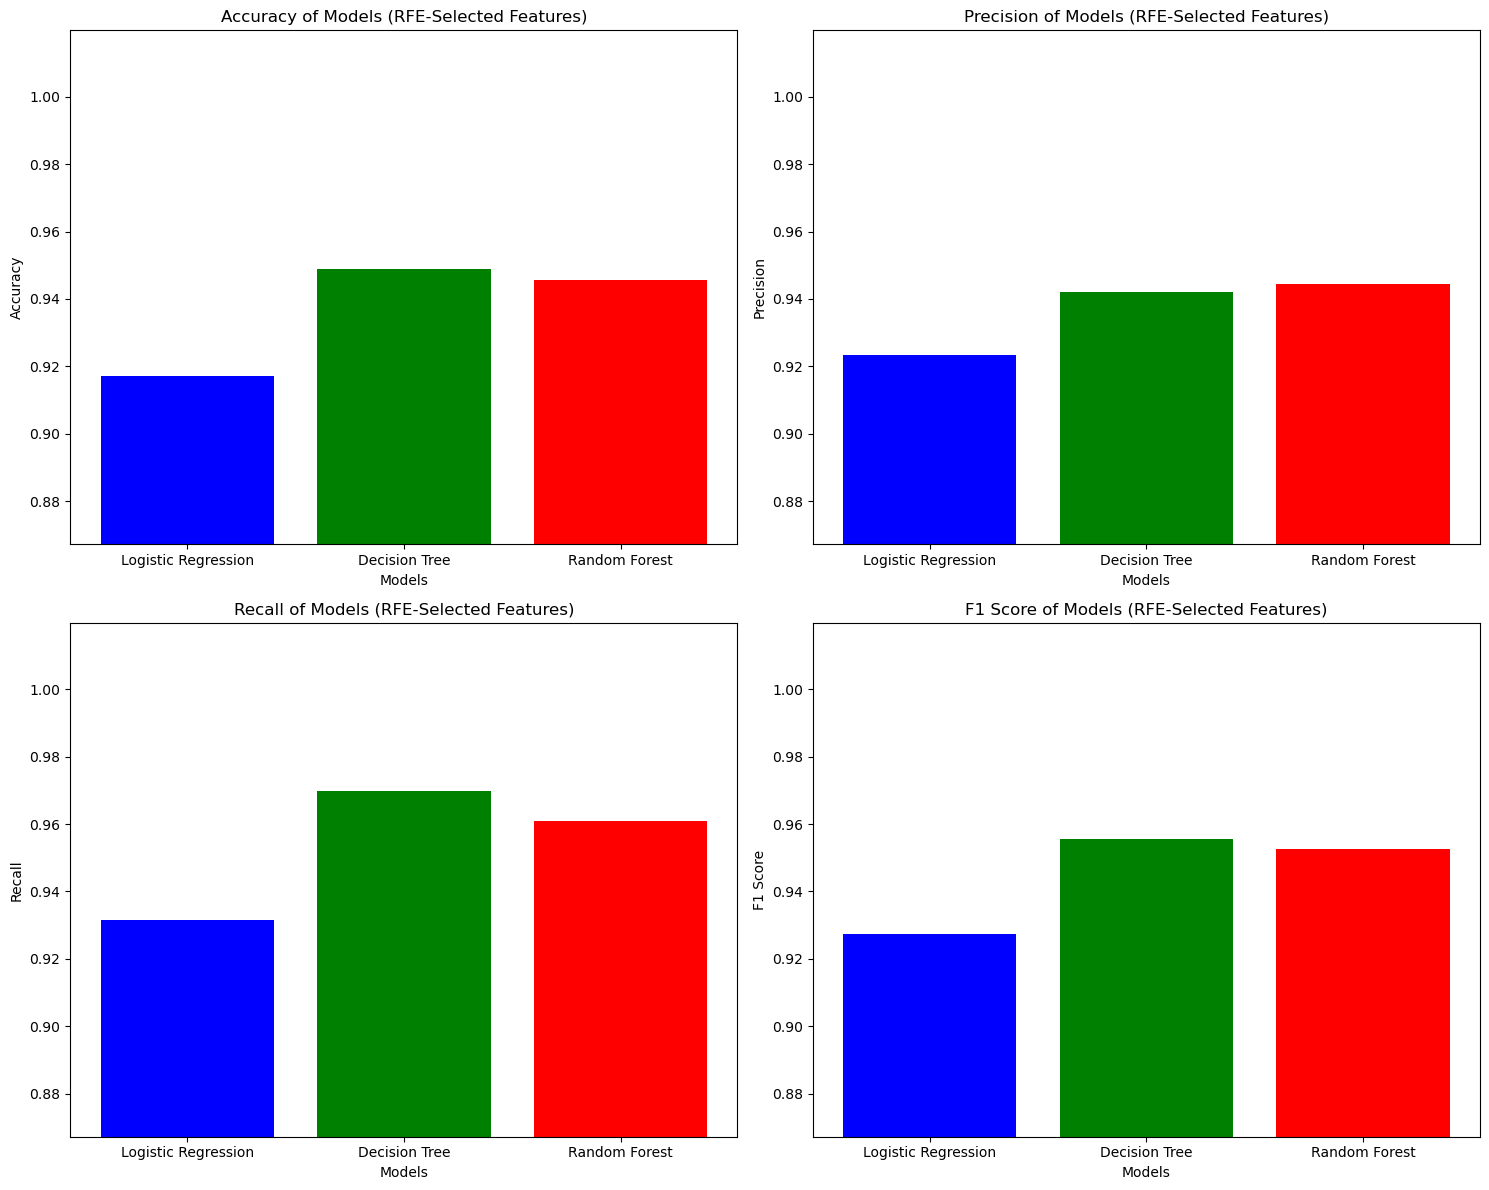

In [104]:
# We will implement a comparison of the performance metrics of the models regarding the RFE-selected features 
# We will plot the metrics in subplots.

# Dynamic y-axis limits
min_y = min(min(accuracy_values), min(precision_values), min(recall_values), min(f1_score_values)) - 0.05
max_y = max(max(accuracy_values), max(precision_values), max(recall_values), max(f1_score_values)) + 0.05

# Plotting metrics in subplots
fig, axs = plt.subplots(2, 2, figsize=(15, 12))

# Accuracy subplot
axs[0, 0].bar(model_names, accuracy_values, color=['blue', 'green', 'red'])
axs[0, 0].set_xlabel('Models')
axs[0, 0].set_ylabel('Accuracy')
axs[0, 0].set_title('Accuracy of Models (RFE-Selected Features)')
axs[0, 0].set_ylim(min_y, max_y)

# Precision subplot
axs[0, 1].bar(model_names, precision_values, color=['blue', 'green', 'red'])
axs[0, 1].set_xlabel('Models')
axs[0, 1].set_ylabel('Precision')
axs[0, 1].set_title('Precision of Models (RFE-Selected Features)')
axs[0, 1].set_ylim(min_y, max_y)

# Recall subplot
axs[1, 0].bar(model_names, recall_values, color=['blue', 'green', 'red'])
axs[1, 0].set_xlabel('Models')
axs[1, 0].set_ylabel('Recall')
axs[1, 0].set_title('Recall of Models (RFE-Selected Features)')
axs[1, 0].set_ylim(min_y, max_y)

# F1 Score subplot
axs[1, 1].bar(model_names, f1_score_values, color=['blue', 'green', 'red'])
axs[1, 1].set_xlabel('Models')
axs[1, 1].set_ylabel('F1 Score')
axs[1, 1].set_title('F1 Score of Models (RFE-Selected Features)')
axs[1, 1].set_ylim(min_y, max_y)

plt.tight_layout()
plt.show()

### **Feature Importances for the Different Models**

#### - Decision Tree & Random Forest Model 

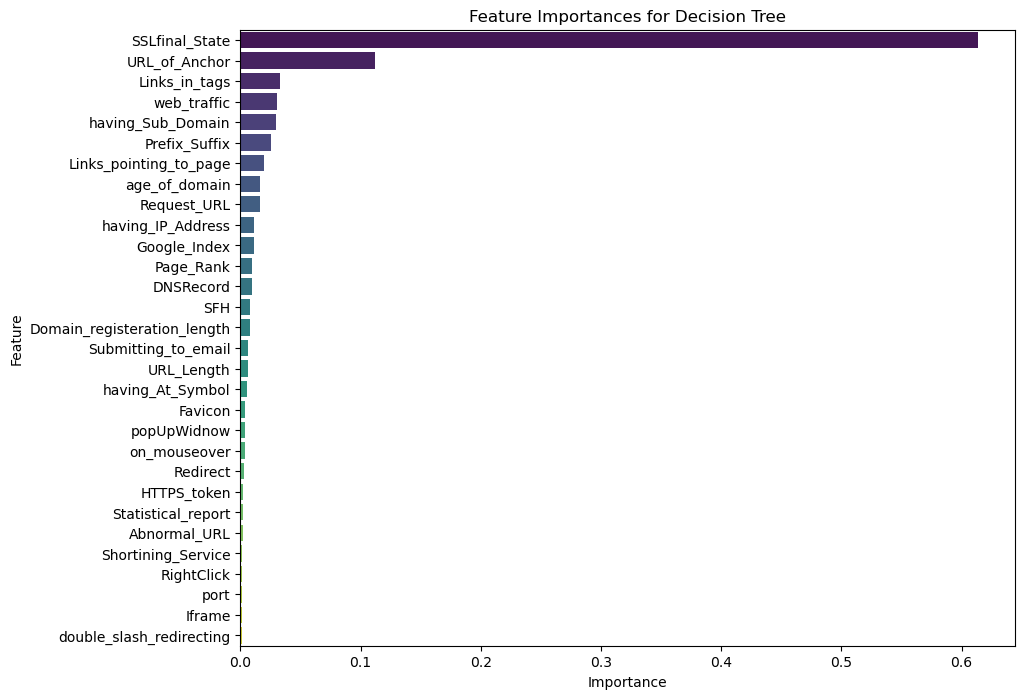

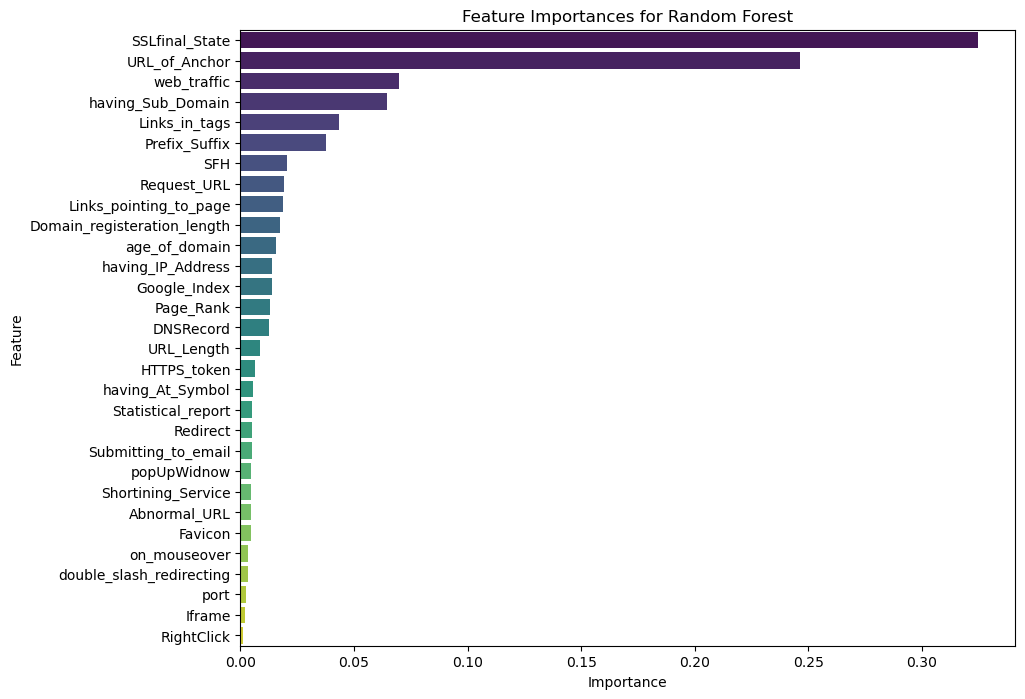

In [105]:
# To store feature importances
feature_importances = {}

for model_name, model in models.items():
    if hasattr(model, 'feature_importances_'):  # Check if the model has 'feature_importances_' attribute
        # Train the model on the original data
        model.fit(X2_train_scaled, y2_train)
        
        # Extracting the feature importances
        importances = model.feature_importances_
        feature_importances[model_name] = importances

        # Creating a DataFrame for visualization
        importance_df = pd.DataFrame({
            'Feature': X2_train.columns,  # Features
            'Importance': importances
        }).sort_values(by='Importance', ascending=False)
        
        # Plotting feature importances
        plt.figure(figsize=(10, 8))
        sns.barplot(x='Importance', y='Feature', data=importance_df, hue='Feature', palette='viridis', legend=False)        
        plt.title(f'Feature Importances for {model_name}')
        plt.xlabel('Importance')
        plt.ylabel('Feature')
        plt.show()
    

#### - Logistic Regression Model 

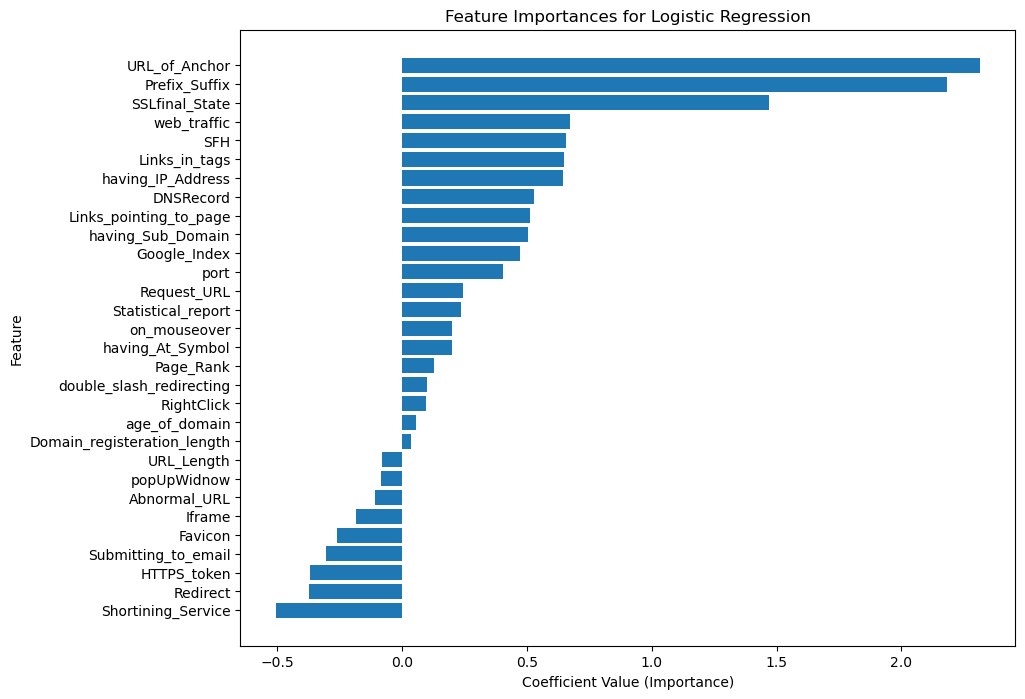

In [106]:
# The feature importances for Logistic Regression will be based on the coefficients of the model

# Train Logistic Regression model
logistic_model = LogisticRegression(max_iter=1000, random_state=42)
logistic_model.fit(X2_train_scaled, y2_train)

# Extracting the coefficients as feature importances
coefficients = logistic_model.coef_[0]

# Creating a DataFrame for visualization
importance_df = pd.DataFrame({
    'Feature': X2_train.columns,  # Replace with actual feature names
    'Importance': coefficients
}).sort_values(by='Importance', ascending=False)

# Plotting the feature importances
plt.figure(figsize=(10, 8))
plt.barh(importance_df['Feature'], importance_df['Importance'])
plt.xlabel('Coefficient Value (Importance)')
plt.ylabel('Feature')
plt.title('Feature Importances for Logistic Regression')
plt.gca().invert_yaxis()  # Inverting the y-axis for better readability
plt.show()

#### - K-Nearest Neighbors Model 

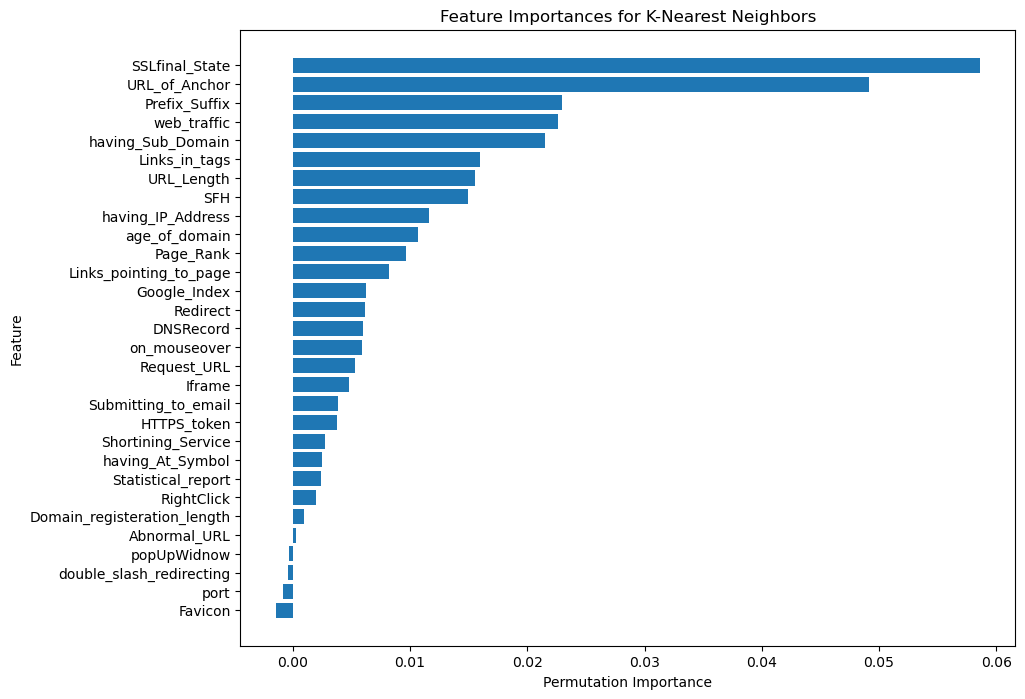

In [107]:
from sklearn.inspection import permutation_importance

# The feature importances for K-Nearest Neighbors will be based on permutation importance

# Train the KNN model
knn_model = KNeighborsClassifier(n_neighbors=5)
knn_model.fit(X2_train_scaled, y2_train)

# Calculate permutation importance
perm_importance = permutation_importance(knn_model, X2_test_scaled, y2_test, scoring='accuracy')

# Creating a DataFrame for better visualization
perm_importance_df = pd.DataFrame({
    'Feature': X2_train.columns,
    'Importance': perm_importance.importances_mean
}).sort_values(by='Importance', ascending=False)

# Plotting the feature importances
plt.figure(figsize=(10, 8))
plt.barh(perm_importance_df['Feature'], perm_importance_df['Importance'])
plt.xlabel('Permutation Importance')
plt.ylabel('Feature')
plt.title('Feature Importances for K-Nearest Neighbors')
plt.gca().invert_yaxis()  # Inverting again the y-axis for better readability
plt.show()

####  **Clustering for Feature Engineering**

#### • k-means clustering

Silhouette score for k=2: 0.284
Silhouette score for k=3: 0.284
Silhouette score for k=4: 0.113
Silhouette score for k=5: 0.107
Silhouette score for k=6: 0.106
Silhouette score for k=7: 0.106
Silhouette score for k=8: 0.091
Silhouette score for k=9: 0.085
Silhouette score for k=10: 0.092


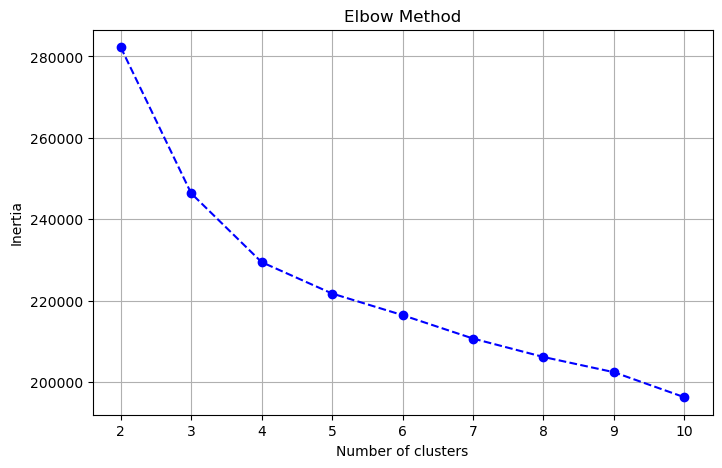

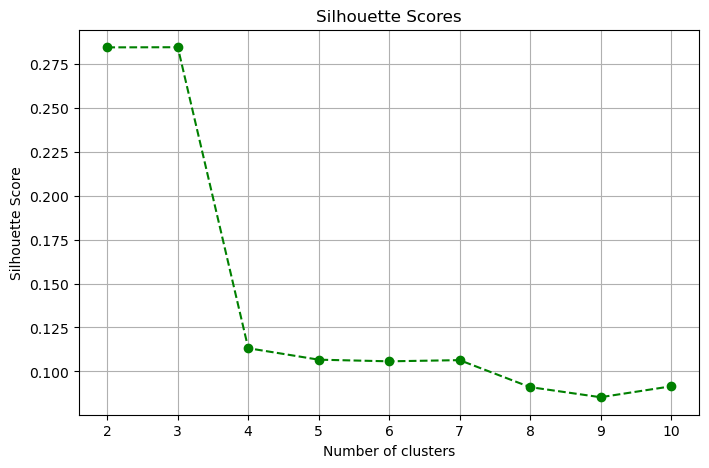

Optimal number of clusters based on silhouette score: 3
'Cluster' labels added to the DataFrame. The updated shape is now: (11055, 31)
Highest silhouette score: 0.284 at k=3


In [108]:
from sklearn.metrics import silhouette_score

# Splitting the data into features and target variable
X_kmeans = phishing_data.drop('Result', axis=1)  # Features of the whole dataset
y_kmeans = phishing_data['Result']  # Target variable 

# Scaling the features
scaler = StandardScaler()
X_scaled_kmeans = scaler.fit_transform(X_kmeans)

# Determining the optimal number of clusters using the elbow method
inertia = []   # Sum of squared distances of samples to their closest cluster center
silhouette_scores = []  # To store silhouette scores
range_k = range(2, 11)   # We will try different numbers of clusters from 2 to 10

for k in range_k:
    kmeans = KMeans(n_clusters=k, random_state=42)  # Creating a KMeans instance with k clusters
    kmeans.fit(X_scaled_kmeans)
    inertia.append(kmeans.inertia_)  # Collecting inertia for the elbow method
    
    # Calculate silhouette score for each k
    cluster_labels = kmeans.predict(X_scaled_kmeans)
    silhouette_avg = silhouette_score(X_scaled_kmeans, cluster_labels)
    silhouette_scores.append(silhouette_avg)
    print(f"Silhouette score for k={k}: {silhouette_avg:.3f}")

# Plotting the Elbow Curve
plt.figure(figsize=(8, 5))
plt.plot(range_k, inertia, marker='o', linestyle='--', color='b')
plt.title("Elbow Method")
plt.xlabel("Number of clusters")
plt.ylabel("Inertia")
plt.grid(True)
plt.show()

# Plotting the Silhouette Scores
plt.figure(figsize=(8, 5))
plt.plot(range_k, silhouette_scores, marker='o', linestyle='--', color='g')
plt.title("Silhouette Scores")
plt.xlabel("Number of clusters")
plt.ylabel("Silhouette Score")
plt.grid(True)
plt.show()

# Automatically determining the optimal number of clusters based on silhouette scores
optimal_k = silhouette_scores.index(max(silhouette_scores)) + 2  # Adjusting for range_k starting at 2
print(f"Optimal number of clusters based on silhouette score: {optimal_k}")

# Fitting KMeans with the optimal number of clusters
kmeans = KMeans(n_clusters=optimal_k, random_state=42)
cluster_labels = kmeans.fit_predict(X_scaled_kmeans)

# Adding the cluster labels as a new feature in the original dataset
X_with_clusters = np.hstack((X_scaled_kmeans, cluster_labels.reshape(-1, 1)))

print(f"'Cluster' labels added to the DataFrame. The updated shape is now: {X_with_clusters.shape}")
# The shape of the data is updated to include the cluster labels. The new shape will have one additional column for the cluster labels.
# The shape of the dataset after adding the k-means Clustering labels will be 31. 
# The original 30 features + 1 new column for clustering labels = 31.

# Automatically determining the optimal number of clusters based on silhouette scores
if not silhouette_scores:
    raise ValueError("Silhouette scores list is empty. Check your data or clustering loop.")

print(f"Highest silhouette score: {max(silhouette_scores):.3f} at k={optimal_k}")

# Fitting KMeans with the optimal number of clusters
kmeans = KMeans(n_clusters=optimal_k, random_state=42)
cluster_labels = kmeans.fit_predict(X_scaled_kmeans)


#### • Evaluating the Impact of Clusters (in the k-means)

• k-means Clustering Visualization (t-SNE)


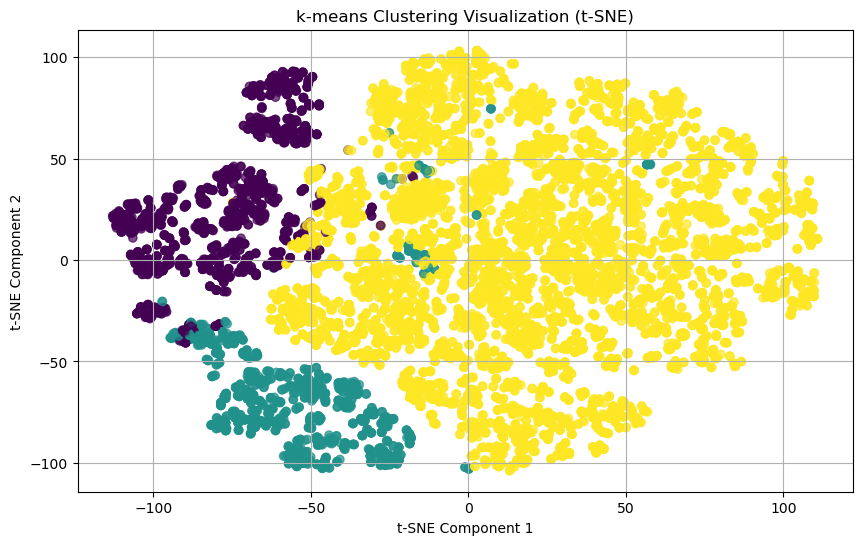

• Model: Random Forest
Accuracy: 0.966
Classification Report:
              precision    recall  f1-score   support

          -1       0.97      0.95      0.96      1428
           1       0.96      0.98      0.97      1889

    accuracy                           0.97      3317
   macro avg       0.97      0.96      0.97      3317
weighted avg       0.97      0.97      0.97      3317

• Model: Decision Tree
Accuracy: 0.956
Classification Report:
              precision    recall  f1-score   support

          -1       0.95      0.94      0.95      1428
           1       0.96      0.96      0.96      1889

    accuracy                           0.96      3317
   macro avg       0.96      0.95      0.95      3317
weighted avg       0.96      0.96      0.96      3317

• Model: Logistic Regression
Accuracy: 0.922
Classification Report:
              precision    recall  f1-score   support

          -1       0.91      0.91      0.91      1428
           1       0.93      0.93      0.93  

In [109]:
from sklearn.manifold import TSNE

# Visualizing the clusters using t-SNE (t-Distributed Stochastic Neighbor Embedding)

# t-SNE visualization
tsne = TSNE(n_components=2, random_state=42)
X_tsne = tsne.fit_transform(X_scaled_kmeans)

print("• k-means Clustering Visualization (t-SNE)")
plt.figure(figsize=(10, 6))
plt.scatter(X_tsne[:, 0], X_tsne[:, 1], c = cluster_labels , cmap='viridis', alpha=0.7)
plt.title("k-means Clustering Visualization (t-SNE)")
plt.xlabel("t-SNE Component 1")
plt.ylabel("t-SNE Component 2")
plt.grid()
plt.show()

# Function to train and evaluate the classifiers
def train_and_evaluate_model(model, X_train, X_test, y_train, y_test, model_name):
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    accuracy = accuracy_score(y_test, y_pred)
    report = classification_report(y_test, y_pred)
    print(f"• Model: {model_name}")
    print(f"Accuracy: {accuracy:.3f}")
    print("Classification Report:")
    print(report)
    return accuracy, report

# Classifiers
classifiers = {
    "Random Forest": RandomForestClassifier(random_state=42),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Logistic Regression": LogisticRegression(max_iter=10000, random_state=42),
    "K-Nearest Neighbors": KNeighborsClassifier(n_neighbors=5)
}

# Splitting the dataset
X_train_clusters, X_tests_clusters, y_train_clusters, y_test_clusters = train_test_split(X_with_clusters, y_kmeans, test_size=0.3, random_state=42)

# Training and evaluating each classifier
results_clusters = {}
for name, classifier in classifiers.items():
    accuracy, report = train_and_evaluate_model(classifier, X_train_clusters, X_tests_clusters, y_train_clusters, y_test_clusters, name)
    results_clusters[name] = {"Accuracy": accuracy, "Classification Report": report}

# Printing the summary of the results of all the classifiers used in the clustering
print("Summary of Results:")
for model_name, result in results_clusters.items():
    print(f"{model_name} - Accuracy: {result['Accuracy']:.3f}")



#### • Agglomerative Clustering 

Silhouette Score (Agglomerative Clustering): 0.267

• Agglomerative Clustering Visualization (t-SNE)


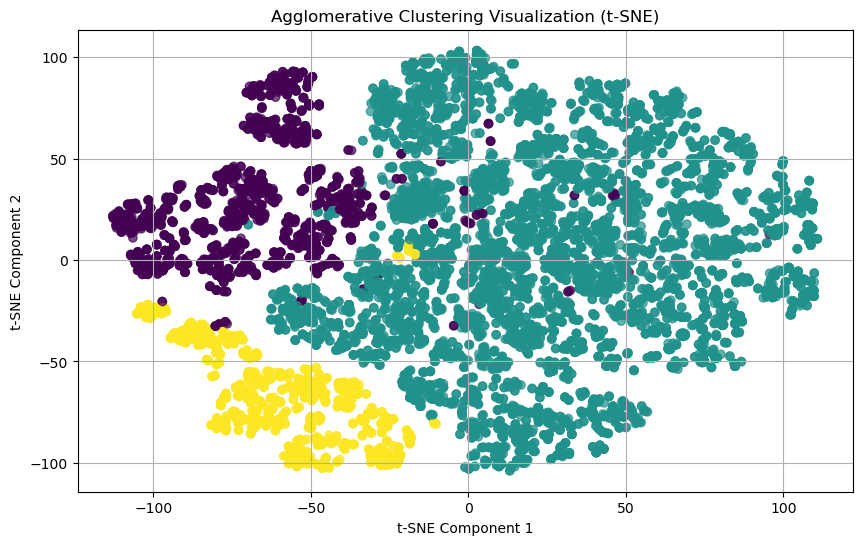

-- Added Agglomerative Clustering labels. New shape: (11055, 31)

• Model: Random Forest
Accuracy: 0.968
Classification Report:
              precision    recall  f1-score   support

          -1       0.98      0.95      0.96      1428
           1       0.96      0.98      0.97      1889

    accuracy                           0.97      3317
   macro avg       0.97      0.97      0.97      3317
weighted avg       0.97      0.97      0.97      3317

• Model: Decision Tree
Accuracy: 0.957
Classification Report:
              precision    recall  f1-score   support

          -1       0.95      0.95      0.95      1428
           1       0.96      0.96      0.96      1889

    accuracy                           0.96      3317
   macro avg       0.96      0.96      0.96      3317
weighted avg       0.96      0.96      0.96      3317

• Model: Logistic Regression
Accuracy: 0.921
Classification Report:
              precision    recall  f1-score   support

          -1       0.91      0.91

In [110]:
# Splitting the data into features and target variable
X_agglomerative = phishing_data.drop('Result', axis=1)  # Features of the whole dataset
y_agglomerative = phishing_data['Result']  # Target variable 

# Scaling the features
scaler = StandardScaler()
X_scaled_agglomerative = scaler.fit_transform(X_agglomerative)

# Performing Agglomerative Clustering
agg_clustering = AgglomerativeClustering(n_clusters=3, linkage='ward')  # Set the number of clusters to match k-means
agg_labels = agg_clustering.fit_predict(X_scaled_agglomerative)

# Evaluate the clustering using silhouette score
agg_silhouette = silhouette_score(X_scaled_agglomerative, agg_labels)
print(f"Silhouette Score (Agglomerative Clustering): {agg_silhouette:.3f}")

# t-SNE visualization for Agglomerative Clustering 
tsne = TSNE(n_components=2, random_state=42)
X_tsne = tsne.fit_transform(X_scaled_agglomerative)

print("\n• Agglomerative Clustering Visualization (t-SNE)")
plt.figure(figsize=(10, 6))
plt.scatter(X_tsne[:, 0], X_tsne[:, 1], c=agg_labels, cmap='viridis', alpha=0.7)
plt.title("Agglomerative Clustering Visualization (t-SNE)")
plt.xlabel("t-SNE Component 1")
plt.ylabel("t-SNE Component 2")
plt.grid()
plt.show()

# Add Agglomerative Clustering labels as a feature
X_with_agg_clusters = np.hstack((X_scaled_agglomerative, agg_labels.reshape(-1, 1)))

print(f"-- Added Agglomerative Clustering labels. New shape: {X_with_agg_clusters.shape}\n")
# The shape of the dataset after adding the Agglomerative Clustering labels will be 31. 
# The original 30 features + 1 new column for clustering labels = 31.

# Splitting the dataset with Agglomerative Clustering labels
X_train_agg, X_test_agg, y_train_agg, y_test_agg = train_test_split(X_with_agg_clusters, y_agglomerative, test_size=0.3, random_state=42)

# Training and evaluating the classifiers
results_agg = {}
for name, classifier in classifiers.items():
    accuracy, report = train_and_evaluate_model(classifier, X_train_agg, X_test_agg, y_train_agg, y_test_agg, name)
    results_agg[name] = {"Accuracy": accuracy, "Classification Report": report}

# Printint the summary results of the classifiers used in the Agglomerative Clustering
print("Summary of Results (Agglomerative Clustering):")
for model_name, result in results_agg.items():
    print(f"{model_name} - Accuracy: {result['Accuracy']:.3f}")

#### - Comparing k-means and Agglomerative Clustering

In [111]:
# Comparing the k-means and Agglomerative Clustering
print("Comparison of Classifier Results:")

for model_name in results_clusters.keys():
    print(f"\n• Model: {model_name}")
    print(f" - k-means Accuracy: {results_clusters[model_name]['Accuracy']:.3f}")
    print(f" - Agglomerative Clustering Accuracy: {results_agg[model_name]['Accuracy']:.3f}")


Comparison of Classifier Results:

• Model: Random Forest
 - k-means Accuracy: 0.966
 - Agglomerative Clustering Accuracy: 0.968

• Model: Decision Tree
 - k-means Accuracy: 0.956
 - Agglomerative Clustering Accuracy: 0.957

• Model: Logistic Regression
 - k-means Accuracy: 0.922
 - Agglomerative Clustering Accuracy: 0.921

• Model: K-Nearest Neighbors
 - k-means Accuracy: 0.932
 - Agglomerative Clustering Accuracy: 0.931


### • **Incorporating Neural Networks**

#### - Multilayer Perceptrons (MLPs)

>Multilayer perceptrons (MLPs) are also known as feed-forward neural networks, or sometimes just neural networks. Multilayer perceptrons can be applied for both classification and regression problems. MLPs can be viewed as generalizations of linear models that perform multiple stages of processing to come to a decision.

In [112]:
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# Splitting the data into features and target variable
X_mlp = phishing_data.drop('Result', axis=1)  # Features
y_mlp = phishing_data['Result']  # Target variable

# Splitting the data into training and testing data
X_train_mlp, X_test_mlp, y_train_mlp, y_test_mlp = train_test_split(X_mlp, y_mlp, test_size=0.2, random_state=42)  # 80% training and 20% testing

# Scaling the features
scaler_mlp = StandardScaler()
X_train_mlp_scaled = scaler_mlp.fit_transform(X_train_mlp)
X_test_mlp_scaled = scaler_mlp.transform(X_test_mlp)

# Defining the different hidden layer configurations for the MLP
# Activation function: tanh, Solver: adam, Maximum number of iterations: 1000
configurations_mlp = [
    {'hidden_layer_sizes': (32,), 'activation': 'tanh', 'solver': 'adam', 'max_iter': 1000},
    {'hidden_layer_sizes': (64,), 'activation': 'tanh', 'solver': 'adam', 'max_iter': 1000},
    {'hidden_layer_sizes': (32, 16), 'activation': 'tanh', 'solver': 'adam', 'max_iter': 1000},
    {'hidden_layer_sizes': (64, 32), 'activation': 'tanh', 'solver': 'adam', 'max_iter': 1000},
    {'hidden_layer_sizes': (64, 32, 16), 'activation': 'tanh', 'solver': 'adam', 'max_iter': 1000}
]

# Additional configurations with ReLU activation function and adam as a Solver 
configurations_mlp2 = [
    {'hidden_layer_sizes': (32,), 'activation': 'relu', 'solver': 'adam', 'max_iter': 1000},
    {'hidden_layer_sizes': (64,), 'activation': 'relu', 'solver': 'adam', 'max_iter': 1000},
    {'hidden_layer_sizes': (32, 16), 'activation': 'relu', 'solver': 'adam', 'max_iter': 1000},
    {'hidden_layer_sizes': (64, 32), 'activation': 'relu', 'solver': 'adam', 'max_iter': 1000},
    {'hidden_layer_sizes': (64, 32, 16), 'activation': 'relu', 'solver': 'adam', 'max_iter': 1000}
]

# Train and evaluate the MLP for each configuration
for config in configurations_mlp + configurations_mlp2:
    mlp = MLPClassifier(**config, random_state=42)  # Ensure consistent results
    mlp.fit(X_train_mlp_scaled, y_train_mlp)  # Use scaled training data
    y_pred_config = mlp.predict(X_test_mlp_scaled)  # Predict on scaled test data
    accuracy = accuracy_score(y_test_mlp, y_pred_config)
    print(f"Configuration info: {config}")
    print(f"Accuracy: {accuracy}\n")

Configuration info: {'hidden_layer_sizes': (32,), 'activation': 'tanh', 'solver': 'adam', 'max_iter': 1000}
Accuracy: 0.9669832654907282

Configuration info: {'hidden_layer_sizes': (64,), 'activation': 'tanh', 'solver': 'adam', 'max_iter': 1000}
Accuracy: 0.9678878335594754

Configuration info: {'hidden_layer_sizes': (32, 16), 'activation': 'tanh', 'solver': 'adam', 'max_iter': 1000}
Accuracy: 0.9633649932157394

Configuration info: {'hidden_layer_sizes': (64, 32), 'activation': 'tanh', 'solver': 'adam', 'max_iter': 1000}
Accuracy: 0.966078697421981

Configuration info: {'hidden_layer_sizes': (64, 32, 16), 'activation': 'tanh', 'solver': 'adam', 'max_iter': 1000}
Accuracy: 0.9633649932157394

Configuration info: {'hidden_layer_sizes': (32,), 'activation': 'relu', 'solver': 'adam', 'max_iter': 1000}
Accuracy: 0.9665309814563546

Configuration info: {'hidden_layer_sizes': (64,), 'activation': 'relu', 'solver': 'adam', 'max_iter': 1000}
Accuracy: 0.9678878335594754

Configuration info: {'

#### Loss Curves for hidden layer sizes 

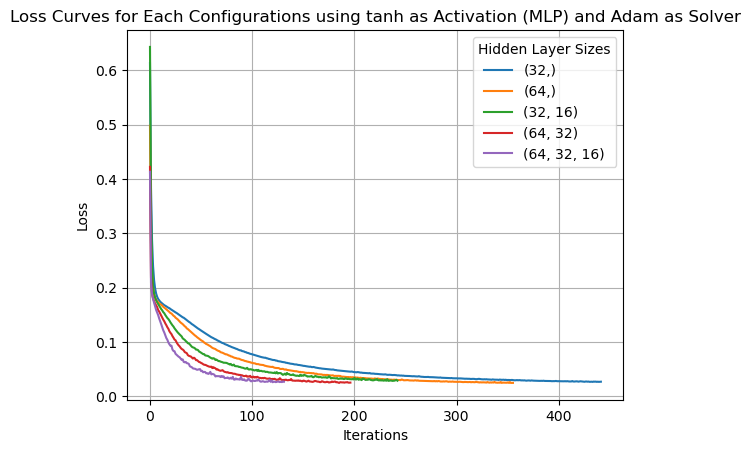

In [113]:
# Plotting the loss curves for all hidden layer sizes of the configurations (tanh as Activation and Adam as Solver)

loss_curves = {}

for config in configurations_mlp:
    mlp = MLPClassifier(**config, random_state=42)
    mlp.fit(X_train_mlp_scaled, y_train_mlp)
    loss_curves[str(config)] = mlp.loss_curve_

# Plot loss curves for all configurations
for config, loss_curve in loss_curves.items():
    plt.plot(loss_curve, label=str(config))
plt.title("Loss Curves for Each Configurations using tanh as Activation (MLP) and Adam as Solver")  
plt.xlabel("Iterations")
plt.ylabel("Loss")
plt.legend(title="Hidden Layer Sizes", loc='upper right', labels=[str(config['hidden_layer_sizes']) for config in configurations_mlp])
plt.grid(True)
plt.show()

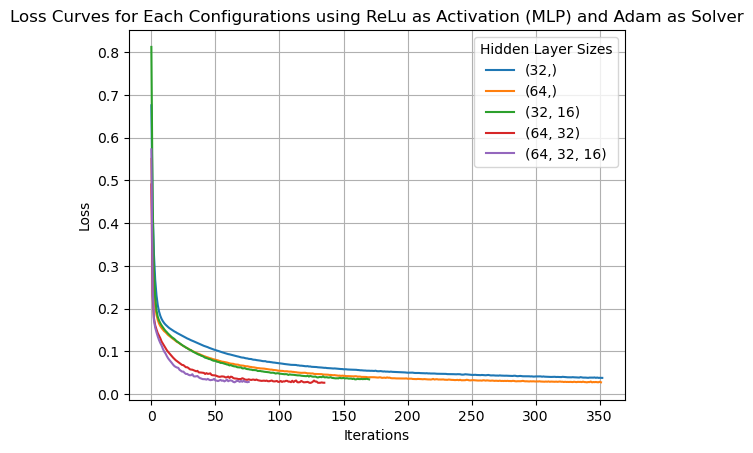

In [114]:
# Plotting the loss curves for all hidden layer sizes of the configurations (ReLU as Activation Function and Adam as Solver)

loss_curves2 = {}

for config in configurations_mlp2 :
    mlp = MLPClassifier(**config, random_state=42)
    mlp.fit(X_train_mlp_scaled, y_train_mlp)
    loss_curves2[str(config)] = mlp.loss_curve_

# Plot loss curves for all configurations
for config, loss_curve in loss_curves2.items():
    plt.plot(loss_curve, label=str(config))
plt.title("Loss Curves for Each Configurations using ReLu as Activation (MLP) and Adam as Solver")  
plt.xlabel("Iterations")
plt.ylabel("Loss")
plt.legend(title="Hidden Layer Sizes", loc='upper right', labels=[str(config['hidden_layer_sizes']) for config in configurations_mlp2])
plt.grid(True)
plt.show()

#### Performing Cross-Validation for each Configuration

In [115]:
# Performing Cross-Validation for each configuration
for config in configurations_mlp + configurations_mlp2:
    mlp = MLPClassifier(**config, random_state=42)
    scores = cross_val_score(mlp, X_train_mlp_scaled, y_train_mlp, cv=5, scoring='accuracy')
    print(f"Configuration: {config}")
    print(f"Cross-validation scores: {scores}")
    print(f"Mean CV score: {scores.mean():.4f}\n")

Configuration: {'hidden_layer_sizes': (32,), 'activation': 'tanh', 'solver': 'adam', 'max_iter': 1000}
Cross-validation scores: [0.9683437  0.96212549 0.96099491 0.96495195 0.96266968]
Mean CV score: 0.9638

Configuration: {'hidden_layer_sizes': (64,), 'activation': 'tanh', 'solver': 'adam', 'max_iter': 1000}
Cross-validation scores: [0.97173544 0.96269079 0.96382137 0.97060486 0.96945701]
Mean CV score: 0.9677

Configuration: {'hidden_layer_sizes': (32, 16), 'activation': 'tanh', 'solver': 'adam', 'max_iter': 1000}
Cross-validation scores: [0.96099491 0.96721311 0.95703787 0.96042962 0.96323529]
Mean CV score: 0.9618

Configuration: {'hidden_layer_sizes': (64, 32), 'activation': 'tanh', 'solver': 'adam', 'max_iter': 1000}
Cross-validation scores: [0.96438666 0.96042962 0.96325608 0.96608253 0.96832579]
Mean CV score: 0.9645

Configuration: {'hidden_layer_sizes': (64, 32, 16), 'activation': 'tanh', 'solver': 'adam', 'max_iter': 1000}
Cross-validation scores: [0.96721311 0.955342   0.96

> Based on all the above analysis, we choose 'tanh' over 'relu' as an activation because tanh performed consistently well for other configurations too.

#### Training and Evaluating the model with the best configuration (best hidden layer size)

In [116]:
# Train the model with the best configuration
best_final_mlp = MLPClassifier(hidden_layer_sizes=(64,), activation='tanh', solver='adam', max_iter=1000, random_state=42)  # we chose 'tanh' over 'relu' as an activation because tanh performed consistently well for other configurations too.
best_final_mlp.fit(X_train_mlp_scaled, y_train_mlp)

# Test set predictions
y_pred_final = best_final_mlp.predict(X_test_mlp_scaled)

# Evaluate the final model
print("Final Model Accuracy on Test Set:", accuracy_score(y_test_mlp, y_pred_final))
print("\nConfusion Matrix:")
print(confusion_matrix(y_test_mlp, y_pred_final))
print("\nClassification Report:")
print(classification_report(y_test_mlp, y_pred_final))

Final Model Accuracy on Test Set: 0.9678878335594754

Confusion Matrix:
[[ 910   46]
 [  25 1230]]

Classification Report:
              precision    recall  f1-score   support

          -1       0.97      0.95      0.96       956
           1       0.96      0.98      0.97      1255

    accuracy                           0.97      2211
   macro avg       0.97      0.97      0.97      2211
weighted avg       0.97      0.97      0.97      2211



####  Experimenting with Different Training Sizes and Evaluating the Results.

Training size: 0.1
Accuracy: 0.928
Precision: 0.934
Recall: 0.939
F1 Score: 0.936

Classification Report:
              precision    recall  f1-score   support

          -1       0.92      0.92      0.92      4398
           1       0.93      0.94      0.94      5552

    accuracy                           0.93      9950
   macro avg       0.93      0.93      0.93      9950
weighted avg       0.93      0.93      0.93      9950

Confusion Matrix:
[[4027  371]
 [ 341 5211]]
---------------------------------------------
Training size: 0.2
Accuracy: 0.942
Precision: 0.942
Recall: 0.956
F1 Score: 0.949

Classification Report:
              precision    recall  f1-score   support

          -1       0.94      0.92      0.93      3888
           1       0.94      0.96      0.95      4956

    accuracy                           0.94      8844
   macro avg       0.94      0.94      0.94      8844
weighted avg       0.94      0.94      0.94      8844

Confusion Matrix:
[[3594  294]
 [ 216 4740]

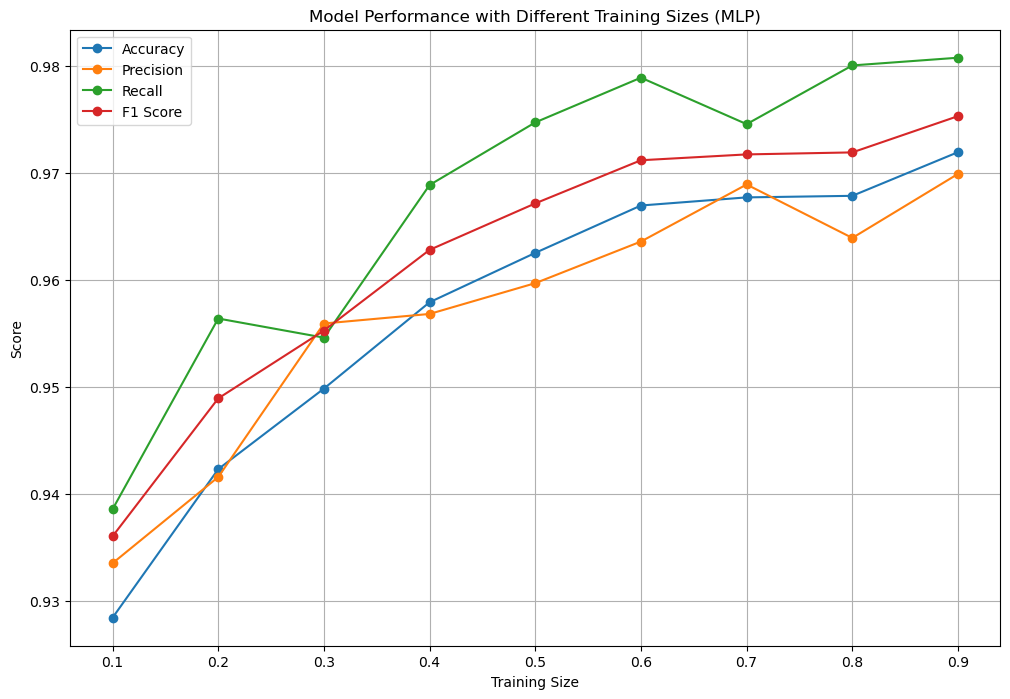

In [117]:
# Defining the different training sizes that we will experiment with
training_sizes = [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9]

# Store the results
results = {
    'training_size': [],
    'accuracy': [],
    'precision': [],
    'recall': [],
    'f1_score': []
}

# Loop through each training size
for size in training_sizes:

    # Splitting the data into training and testing sets with the current training size
    X_train_diff_trS, X_test_diff_trS, y_train_diff_trS, y_test_diff_trS = train_test_split(X_mlp, y_mlp, train_size=size, random_state=42)
    
    # Scale the features
    scaler_diff_trS = StandardScaler()
    X_train_scaled_diff_trS = scaler_diff_trS.fit_transform(X_train_diff_trS)
    X_test_scaled_diff_trS = scaler_diff_trS.transform(X_test_diff_trS)
    
    # Train the model with the current training size
    best_mlp = MLPClassifier(hidden_layer_sizes=(64,), activation='tanh', solver='adam', max_iter=1000, random_state=42)  # Using the best configuration based on the above experiments
    best_mlp.fit(X_train_scaled_diff_trS, y_train_diff_trS)
    
    # Make predictions on the test set
    y_pred_diff_trS = best_mlp.predict(X_test_scaled_diff_trS)
    
    # Evaluate the model
    accuracy = accuracy_score(y_test_diff_trS, y_pred_diff_trS)
    precision = precision_score(y_test_diff_trS, y_pred_diff_trS)
    recall = recall_score(y_test_diff_trS, y_pred_diff_trS)
    f1 = f1_score(y_test_diff_trS, y_pred_diff_trS)
    
    # Store the results
    results['training_size'].append(size)
    results['accuracy'].append(accuracy)
    results['precision'].append(precision)
    results['recall'].append(recall)
    results['f1_score'].append(f1)
    
    # Print the results for the current training size
    print(f"Training size: {size}")
    print(f"Accuracy: {accuracy:.3f}")
    print(f"Precision: {precision:.3f}")
    print(f"Recall: {recall:.3f}")
    print(f"F1 Score: {f1:.3f}")
    print("\nClassification Report:")
    print(classification_report(y_test_diff_trS, y_pred_diff_trS))
    print("Confusion Matrix:")
    print(confusion_matrix(y_test_diff_trS, y_pred_diff_trS))
    print("---------------------------------------------")

# Plotting the results
plt.figure(figsize=(12, 8))
plt.plot(results['training_size'], results['accuracy'], label='Accuracy', marker='o')
plt.plot(results['training_size'], results['precision'], label='Precision', marker='o')
plt.plot(results['training_size'], results['recall'], label='Recall', marker='o')
plt.plot(results['training_size'], results['f1_score'], label='F1 Score', marker='o')
plt.xlabel('Training Size')
plt.ylabel('Score')
plt.title('Model Performance with Different Training Sizes (MLP)')
plt.legend()
plt.grid(True)
plt.show()

#### Plotting the Training Loss Vs Training Size

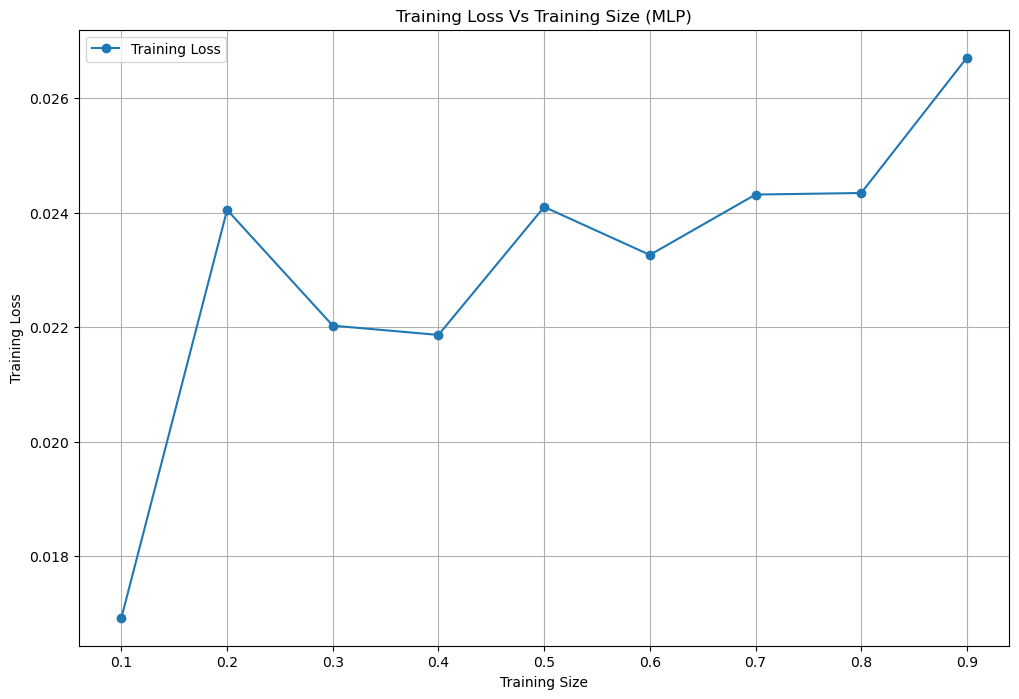

In [118]:
# Storing the results
results = {
    'training_size': [],
    'loss': []
}

# Loop through each training size
for size in training_sizes:
    # Splitting the data into training and testing sets with the current training size
    X_train_diff_trS, X_test_diff_trS, y_train_diff_trS, y_test_diff_trS = train_test_split(X_mlp, y_mlp, train_size=size, random_state=42)
    
    # Scale the features
    scaler_diff_trS = StandardScaler()
    X_train_scaled_diff_trS = scaler_diff_trS.fit_transform(X_train_diff_trS)
    X_test_scaled_diff_trS = scaler_diff_trS.transform(X_test_diff_trS)
    
    # Train the model with the current training size
    best_mlp = MLPClassifier(hidden_layer_sizes=(64,), activation='tanh', solver='adam', max_iter=1000, random_state=42)  # Using the best configuration based on the above experiments
    best_mlp.fit(X_train_scaled_diff_trS, y_train_diff_trS)
    
    # Store the results
    results['training_size'].append(size)
    results['loss'].append(best_mlp.loss_curve_[-1])  # Store the final loss value

# Plotting the results
plt.figure(figsize=(12, 8))
plt.plot(results['training_size'], results['loss'], label='Training Loss', marker='o')
plt.xlabel('Training Size')
plt.ylabel('Training Loss')
plt.title('Training Loss Vs Training Size (MLP)')
plt.legend()
plt.grid(True)
plt.show()

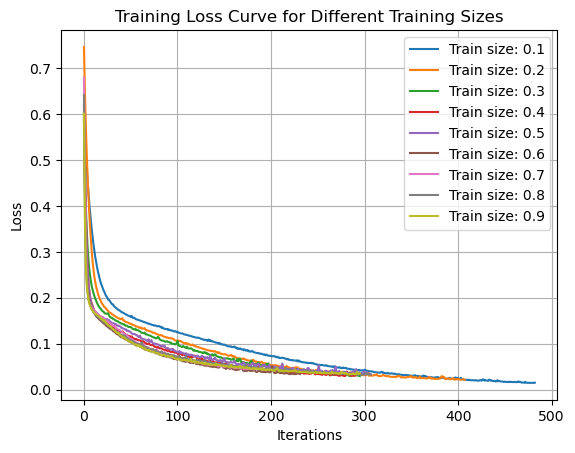

In [119]:
# For each training size we used before, we plot the loss curve
for size in training_sizes:
    X_train_sub, _, y_train_sub, _ = train_test_split(X_train_mlp, y_train_mlp, train_size=size, random_state=42)
    mlp = MLPClassifier(hidden_layer_sizes=(32, 16), activation='tanh', solver='adam', max_iter=2000)
    mlp.fit(X_train_sub, y_train_sub)
    plt.plot(mlp.loss_curve_, label=f'Train size: {size}')

plt.title('Training Loss Curve for Different Training Sizes')
plt.xlabel('Iterations')
plt.ylabel('Loss')
plt.legend()
plt.grid()
plt.show()

#### - Perceptron Classification Model 

> A perceptron is one of the simplest types of artificial neural networks and it's a machine-based algorithm used for supervised learning of various binary sorting tasks.

> We will also perform a cross validation in this step.

In [120]:
from sklearn.linear_model import Perceptron

# Splitting the data into features and target variable
X_perceptron = phishing_data.drop('Result', axis=1)  # Features
y_perceptron = phishing_data['Result']  # Target variable

# Splitting the data into training and testing sets
X_train_perceptron, X_test_perceptron, y_train_perceptron, y_test_perceptron = train_test_split(X_perceptron, y_perceptron, test_size=0.2, random_state=42)

# Standardizing the data
scaler_perceptron = StandardScaler()
X_train_perceptron = scaler_perceptron.fit_transform(X_train_perceptron)
X_test_perceptron = scaler_perceptron.transform(X_test_perceptron)

# Defining the Perceptron model
perceptron_model = Perceptron(max_iter=1000, random_state=42)

# Training the model
perceptron_model.fit(X_train_perceptron, y_train_perceptron)

# Making predictions on the test set
y_pred_perceptron = perceptron_model.predict(X_test_perceptron)

# Evaluating the model
accuracy_perceptron = accuracy_score(y_test_perceptron, y_pred_perceptron)
print(f"Accuracy of the Perceptron model: {accuracy_perceptron:.3f}")

print("\nClassification Report for the Perceptron model:\n", classification_report(y_test_perceptron, y_pred_perceptron))
print("Confusion Matrix (Perceptron):\n", confusion_matrix(y_test_perceptron, y_pred_perceptron))

# Cross-Validation for Perceptron model
perceptron_model = Perceptron(max_iter=1000, tol=1e-3, random_state=42)

scores = cross_val_score(perceptron_model, X_perceptron, y_perceptron, cv=5)
print("\nCross-Validation Accuracy:", scores.mean())


Accuracy of the Perceptron model: 0.907

Classification Report for the Perceptron model:
               precision    recall  f1-score   support

          -1       0.89      0.90      0.89       956
           1       0.92      0.91      0.92      1255

    accuracy                           0.91      2211
   macro avg       0.90      0.91      0.91      2211
weighted avg       0.91      0.91      0.91      2211

Confusion Matrix (Perceptron):
 [[ 859   97]
 [ 109 1146]]

Cross-Validation Accuracy: 0.8685662596110358


#### • XGBoost Classification Model

XGBoost: Accuracy on training Data: 0.989
XGBoost : Accuracy on test Data: 0.971
Precision: 0.965
Recall: 0.984
F1 Score: 0.974

Classification Report:
              precision    recall  f1-score   support

           0       0.98      0.95      0.97       956
           1       0.96      0.98      0.97      1255

    accuracy                           0.97      2211
   macro avg       0.97      0.97      0.97      2211
weighted avg       0.97      0.97      0.97      2211

Confusion Matrix:
[[ 911   45]
 [  20 1235]]


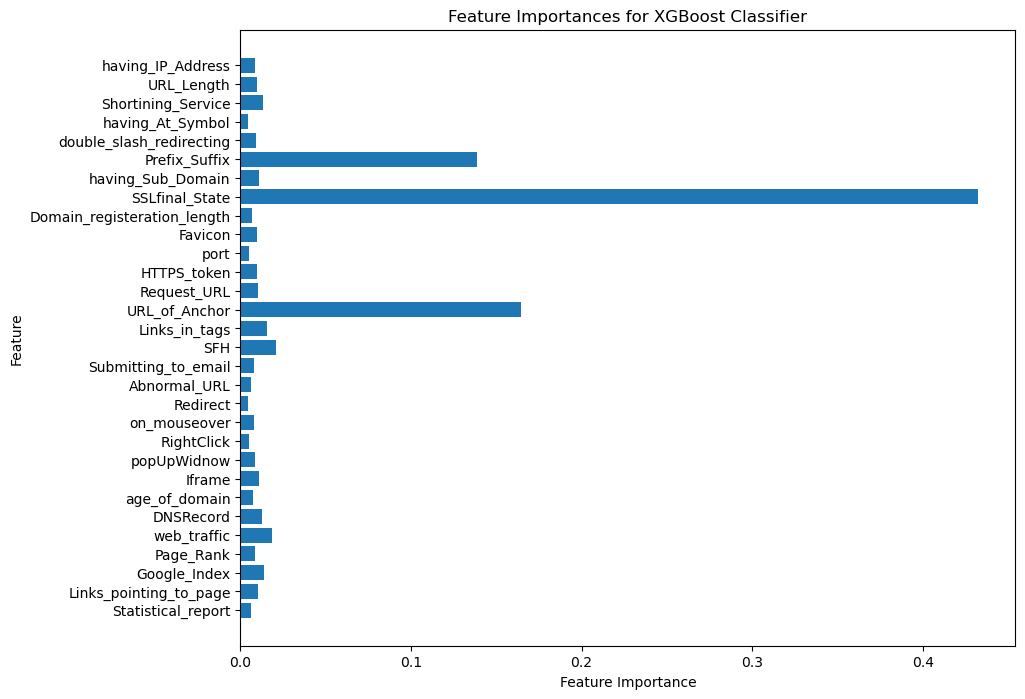

In [121]:
#XGBoost Classification model
from xgboost import XGBClassifier

# Defining the XGBoost model Classifier 
xgb = XGBClassifier(learning_rate=0.4, max_depth=7)  # we chose a learning rate of 0.4 and a max depth of 7. Learning rate determines the step size for updating weights whilst the max depth is the maximum depth of the decision trees.

# Converting the target variable to binary. Since the y has values of -1 and 1, we will convert -1 to 0 and leave 1 as is. 
y_mlp22 = y_mlp.map({-1: 0, 1: 1})  # Convert -1 to 0 and leave 1 as is

X_train22, X_test22, y_train22, y_test22 = train_test_split(X_mlp, y_mlp22, test_size=0.2, random_state=42)  # 80% training and 20% testing

#fitting the model
xgb.fit(X_train22, y_train22)

#predicting the target value from the model for the samples
y_test_xgb = xgb.predict(X_test22)
y_train_xgb = xgb.predict(X_train22)

y_pred_xgb = xgb.predict(X_test22)

#computing the accuracy of the model performance
acc_train_xgb = accuracy_score(y_train22,y_train_xgb)
acc_test_xgb = accuracy_score(y_test22,y_test_xgb)

print("XGBoost: Accuracy on training Data: {:.3f}".format(acc_train_xgb))
print("XGBoost : Accuracy on test Data: {:.3f}".format(acc_test_xgb))


print("Precision: {:.3f}".format(precision_score(y_test22, y_test_xgb)))
print("Recall: {:.3f}".format(recall_score(y_test22, y_test_xgb)))
print("F1 Score: {:.3f}".format(f1_score(y_test22, y_test_xgb)))

print("\nClassification Report:")
print(classification_report(y_test22, y_test_xgb))
print("Confusion Matrix:")
print(confusion_matrix(y_test22, y_test_xgb))

# Plotting the feature importances
plt.figure(figsize=(10, 8))
plt.barh(X_train22.columns, xgb.feature_importances_)
plt.xlabel('Feature Importance')
plt.ylabel('Feature')
plt.title('Feature Importances for XGBoost Classifier')
plt.gca().invert_yaxis()  # Inverting the y-axis for better readability
plt.show()

In [122]:
# Printing the value counts of the target variable to see that we only changed the mapping regarding the -1 values and no data was lost.

print("Value Counts before mapping:\n", y_mlp.value_counts())
print("\nValue Counts after mapping (changed the value of -1 to 0):\n", y_mlp22.value_counts())

Value Counts before mapping:
 Result
 1    6157
-1    4898
Name: count, dtype: int64

Value Counts after mapping (changed the value of -1 to 0):
 Result
1    6157
0    4898
Name: count, dtype: int64


#### Support Vector Machines (SVM) 

#### **- SVC**

In [123]:
from sklearn.svm import SVC
from sklearn.metrics import mean_squared_error

# Splitting the data into features and target variable
X_SVM = phishing_data.drop('Result', axis=1)  # Features
y_SVM = phishing_data['Result']  # Target variable

# Splitting the data into training and testing sets
X_train_SVM, X_test_SVM, y_train_SVM, y_test_SVM = train_test_split(X_SVM, y_SVM, test_size=0.2, random_state=42)

scaler_SVM = StandardScaler()
X_train_SVM = scaler_SVM.fit_transform(X_train_SVM)
X_test_SVM = scaler_SVM.transform(X_test_SVM)

# Comparing the different kernels
kernels = ['linear', 'poly', 'rbf', 'sigmoid']
for kernel in kernels:
    print(f"\nKernel: {kernel}")
    svm_model = SVC(kernel=kernel)
    svm_model.fit(X_train_SVM, y_train_SVM)
    y_pred_SVM = svm_model.predict(X_test_SVM)
    print("Accuracy for SVM (with SVC):", accuracy_score(y_test_SVM, y_pred_SVM))
    print("Classification Report:\n", classification_report(y_test_SVM, y_pred_SVM))
    print("Confusion Matrix:\n", confusion_matrix(y_test_SVM, y_pred_SVM))
    print("\nMean Squared Error:", mean_squared_error(y_test_SVM, y_pred_SVM))
    print("--------------------------------------------------")



Kernel: linear
Accuracy for SVM (with SVC): 0.9285391225689733
Classification Report:
               precision    recall  f1-score   support

          -1       0.93      0.90      0.92       956
           1       0.93      0.95      0.94      1255

    accuracy                           0.93      2211
   macro avg       0.93      0.93      0.93      2211
weighted avg       0.93      0.93      0.93      2211

Confusion Matrix:
 [[ 861   95]
 [  63 1192]]

Mean Squared Error: 0.2858435097241067
--------------------------------------------------

Kernel: poly
Accuracy for SVM (with SVC): 0.9502487562189055
Classification Report:
               precision    recall  f1-score   support

          -1       0.96      0.92      0.94       956
           1       0.94      0.97      0.96      1255

    accuracy                           0.95      2211
   macro avg       0.95      0.95      0.95      2211
weighted avg       0.95      0.95      0.95      2211

Confusion Matrix:
 [[ 882   74]
 [ 

Kernel Comparison based on the above results:

> Best Kernels: rbf and poly; both achieve high accuracy, recall, and F1-scores

The results on both best kernels are quite the same, hence we will stick with the **rbf** kernel as the best choice since its provides the best overal performance and has the lowest false positives and false negatives, indicating a better generalization.


#### Cross Validation (SVC)

Following, we will validate the RBF kernel's performance using k-fold cross-validation

In [124]:
# Performing k-fold cross-validation
scores_SVM = cross_val_score(SVC(kernel='rbf', C=1, gamma=0.1), X_SVM, y_SVM, cv=5)
print("Cross-Validation Scores:", scores_SVM)
print("Mean CV Accuracy:", scores_SVM.mean())

best_kernel = 'rbf'
svm_model_rbf = SVC(kernel=best_kernel)
svm_model_rbf.fit(X_train_SVM, y_train_SVM)
y_pred_SVM_rbf = svm_model_rbf.predict(X_test_SVM)

Cross-Validation Scores: [0.95974672 0.96291271 0.96698327 0.9434645  0.94572592]
Mean CV Accuracy: 0.9557666214382632


#### **Comparison of Neural Network Models** 

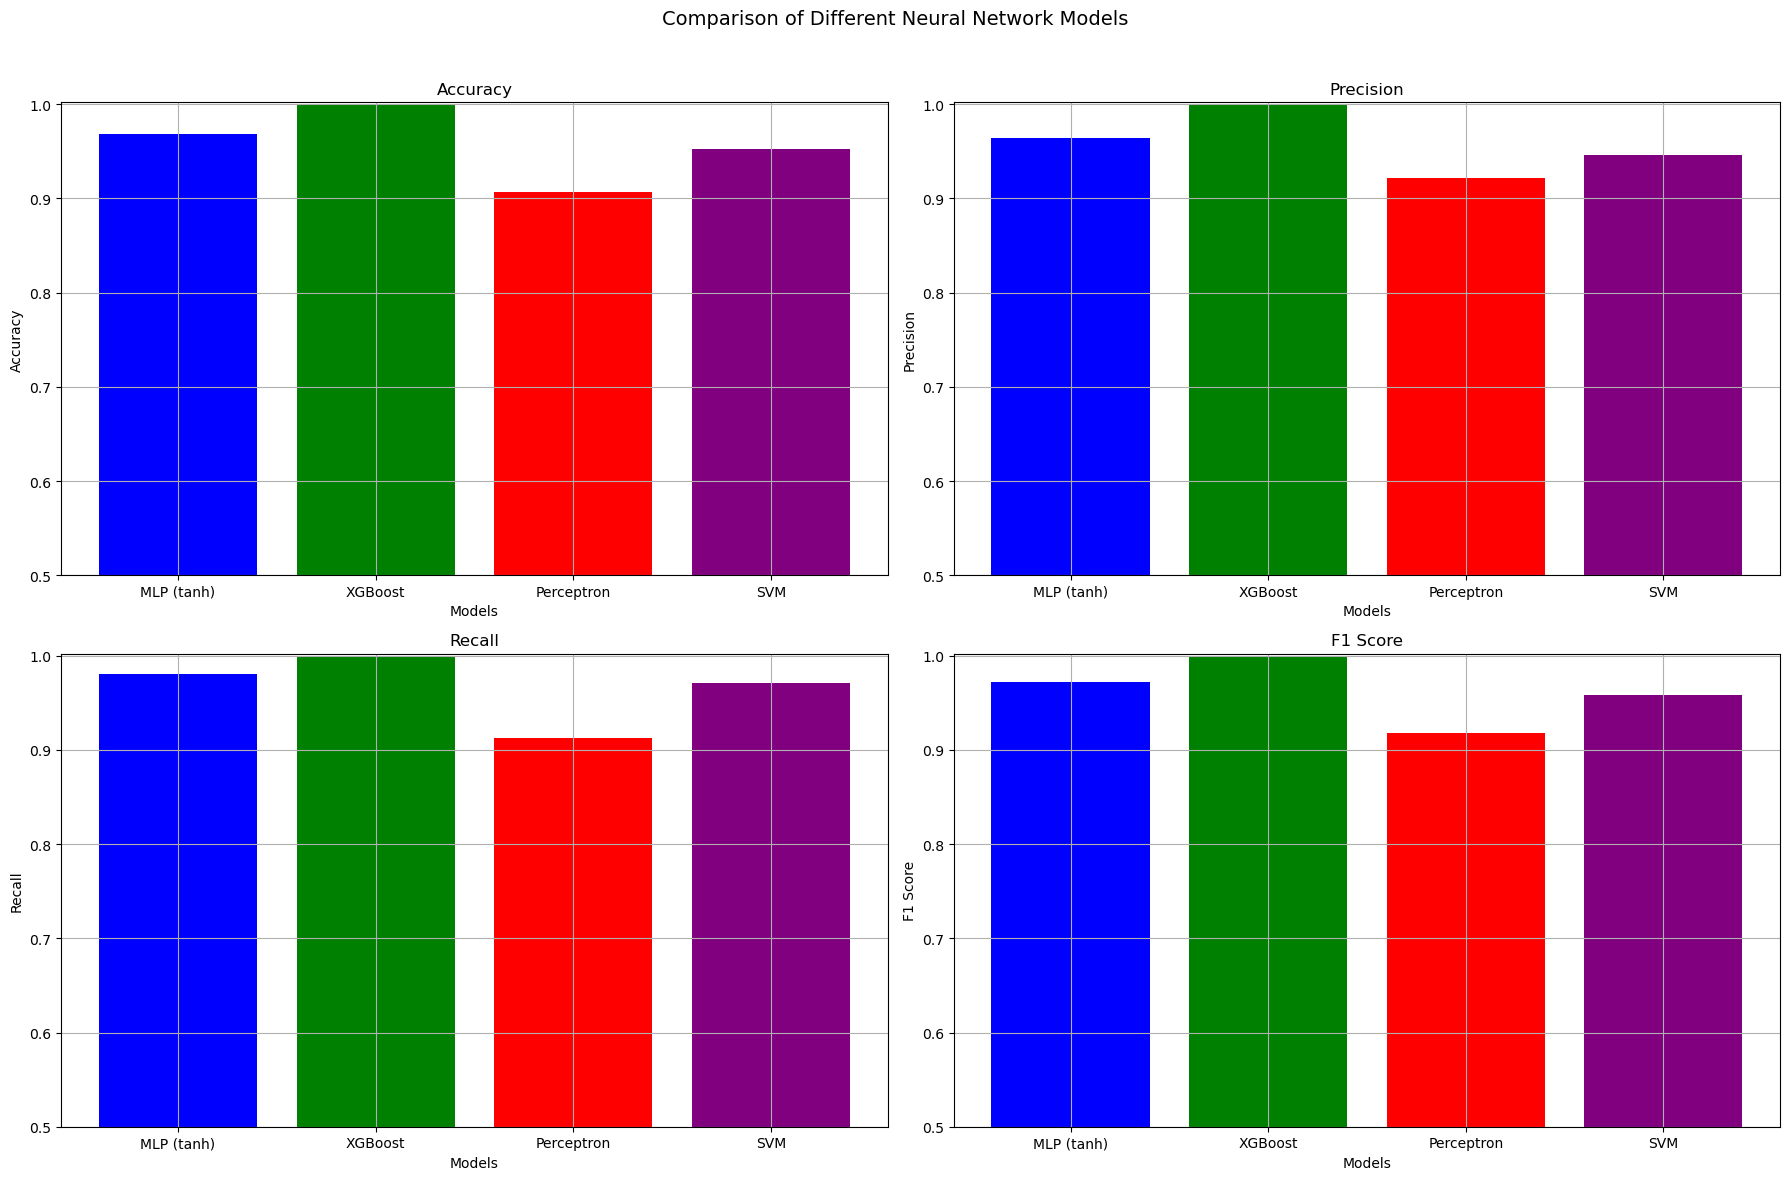

In [125]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.neural_network import MLPClassifier

# Dictionary to store predictions for all models
predictions = {
    "MLP (tanh)": y_pred_final,  # Precomputed predictions for the best MLP model   
    "XGBoost": y_pred_xgb,  # Precomputed predictions for XGBoost
    "Perceptron": y_pred_perceptron,  # Precomputed predictions for Perceptron
    "SVM": y_pred_SVM_rbf,  # Precomputed predictions for SVM
}

# Metric functions
metrics = {
    'accuracy': accuracy_score,
    'precision': precision_score,
    'recall': recall_score,
    'f1': f1_score
}

# Initialize results storage
results = {metric: [] for metric in metrics.keys()}

# Append scores for each model
for metric, func in metrics.items():
    # MLP (tanh)
    results[metric].append(func(y_test_mlp, predictions["MLP (tanh)"]))
    # XGBoost
    results[metric].append(func(y_test_xgb, predictions["XGBoost"]))
    # Perceptron
    results[metric].append(func(y_test_perceptron, predictions["Perceptron"]))
    # SVM 
    results[metric].append(func(y_test_SVM, predictions["SVM"]))
    

# Neural network model names
nn_models = ['MLP (tanh)', 'XGBoost', 'Perceptron', 'SVM']


# Plotting the metrics for each model
fig, axs = plt.subplots(2, 2, figsize=(18, 12))  # Adjusted to 2 rows and 2 columns
fig.suptitle('Comparison of Different Neural Network Models', fontsize=14)

metric_titles = ["Accuracy", "Precision", "Recall", "F1 Score"]
colors = ['blue', 'green', 'red', 'purple']

for idx, metric in enumerate(results.keys()):
    ax = axs[idx // 2, idx % 2]  # Adjusted for 2x2 grid
    ax.bar(nn_models, results[metric], color=colors)
    ax.set_xlabel('Models')
    ax.set_ylabel(metric_titles[idx])
    ax.set_title(f'{metric_titles[idx]}')
    ax.set_ylim(0.5, 1.002)  
    ax.grid(True)

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()


#### - Autoencoder Neural Network

Epoch 1/50
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 1.0401 - val_loss: 0.9712
Epoch 2/50
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.9407 - val_loss: 0.8982
Epoch 3/50
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 998us/step - loss: 0.8860 - val_loss: 0.8440
Epoch 4/50
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 974us/step - loss: 0.8259 - val_loss: 0.8059
Epoch 5/50
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 961us/step - loss: 0.7989 - val_loss: 0.7788
Epoch 6/50
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 972us/step - loss: 0.7768 - val_loss: 0.7565
Epoch 7/50
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 962us/step - loss: 0.7440 - val_loss: 0.7359
Epoch 8/50
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 952us/step - loss: 0.7311 - val_loss: 0.7168
Epoch 9/50
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 969us/step - loss: 0.7156 - val_loss: 0.6997
Epoch 10/50
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 963us/step - loss: 0.6972 - val_loss: 0.6852
Epoch 11/50
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 946us/step - loss: 0.6866 - val_loss: 0.6724
Epoch 12/50
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 952us/step - l

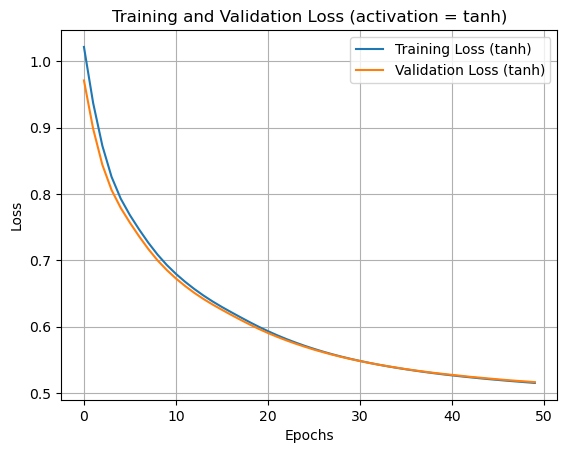

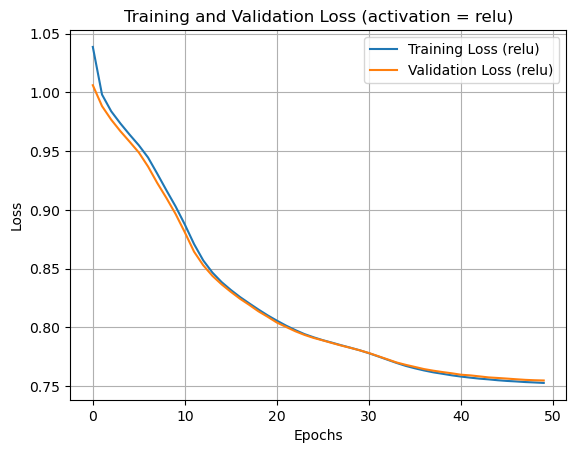

277/277 ━━━━━━━━━━━━━━━━━━━━ 0s 200us/step
70/70 ━━━━━━━━━━━━━━━━━━━━ 0s 254us/step
277/277 ━━━━━━━━━━━━━━━━━━━━ 0s 202us/step
70/70 ━━━━━━━━━━━━━━━━━━━━ 0s 240us/step

Encoded training data shape (tanh): (8844, 7)
Encoded test data shape (tanh): (2211, 7)

Encoded training data shape (relu): (8844, 7)
Encoded test data shape (relu): (2211, 7)


In [126]:
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense
from tensorflow.keras.optimizers import Adam
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

# Splitting the data into features and target variable
X_autoencoder = phishing_data.drop('Result', axis=1)  # Features
y_autoencoder = phishing_data['Result']  # Target variable

# Splitting the data into training and testing sets
X_train_autoencoder, X_test_autoencoder, y_train_autoencoder, y_test_autoencoder = train_test_split(X_autoencoder, y_autoencoder, test_size=0.2, random_state=42) # 80% training and 20% testing

# Standardizing the data
scaler_autoencoder = StandardScaler()
X_train_autoencoder = scaler_autoencoder.fit_transform(X_train_autoencoder)
X_test_autoencoder = scaler_autoencoder.transform(X_test_autoencoder)

# Defining the dimensions of the input and the encoding
input_dim = X_train_autoencoder.shape[1]  # Number of features
encoding_dim = 14   # We chose 14 as the encoding dimension

def build_autoencoder(activation):
    # Input layer
    input_layer = Input(shape=(input_dim,))

    # Encoder layers
    encoded = Dense(encoding_dim, activation=activation)(input_layer)
    encoded = Dense(encoding_dim // 2, activation=activation)(encoded)

    # Decoder layers
    decoded = Dense(encoding_dim // 2, activation=activation)(encoded)
    decoded = Dense(input_dim, activation=activation)(decoded)

    # Autoencoder model
    autoencoder = Model(input_layer, decoded)
    return autoencoder

# Build and compile the autoencoder models
autoencoder_tanh = build_autoencoder('tanh')
autoencoder_relu = build_autoencoder('relu')

autoencoder_tanh.compile(optimizer=Adam(learning_rate=0.001), loss='mean_squared_error')
autoencoder_relu.compile(optimizer=Adam(learning_rate=0.001), loss='mean_squared_error')

# Train the models
history_tanh = autoencoder_tanh.fit(X_train_autoencoder, X_train_autoencoder,
                                    epochs=50,
                                    batch_size=256,
                                    shuffle=True,
                                    validation_data=(X_test_autoencoder, X_test_autoencoder))

history_relu = autoencoder_relu.fit(X_train_autoencoder, X_train_autoencoder,
                                    epochs=50,
                                    batch_size=256,
                                    shuffle=True,
                                    validation_data=(X_test_autoencoder, X_test_autoencoder))

# Encoder models
encoder_tanh = Model(autoencoder_tanh.input, autoencoder_tanh.layers[-3].output)
encoder_relu = Model(autoencoder_relu.input, autoencoder_relu.layers[-3].output)

# Displaying the training loss and validation loss for tanh
plt.plot(history_tanh.history['loss'], label='Training Loss (tanh)')
plt.plot(history_tanh.history['val_loss'], label='Validation Loss (tanh)')
plt.title('Training and Validation Loss (activation = tanh)')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()

# Displaying the training loss and validation loss for relu
plt.plot(history_relu.history['loss'], label='Training Loss (relu)')
plt.plot(history_relu.history['val_loss'], label='Validation Loss (relu)')
plt.title('Training and Validation Loss (activation = relu)')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()

# Encoding the training data
encoded_train_tanh = encoder_tanh.predict(X_train_autoencoder)
encoded_test_tanh = encoder_tanh.predict(X_test_autoencoder)

encoded_train_relu = encoder_relu.predict(X_train_autoencoder)
encoded_test_relu = encoder_relu.predict(X_test_autoencoder)

print(f"\nEncoded training data shape (tanh): {encoded_train_tanh.shape}")
print(f"Encoded test data shape (tanh): {encoded_test_tanh.shape}")

print(f"\nEncoded training data shape (relu): {encoded_train_relu.shape}")
print(f"Encoded test data shape (relu): {encoded_test_relu.shape}")

> Based on the above plots tanh activation appears to perform better, as it achieves a lower final loss for both training and validation compared to the ReLU activation.

#### • **Comparing the classification models by using ROC and calculating the AUC**

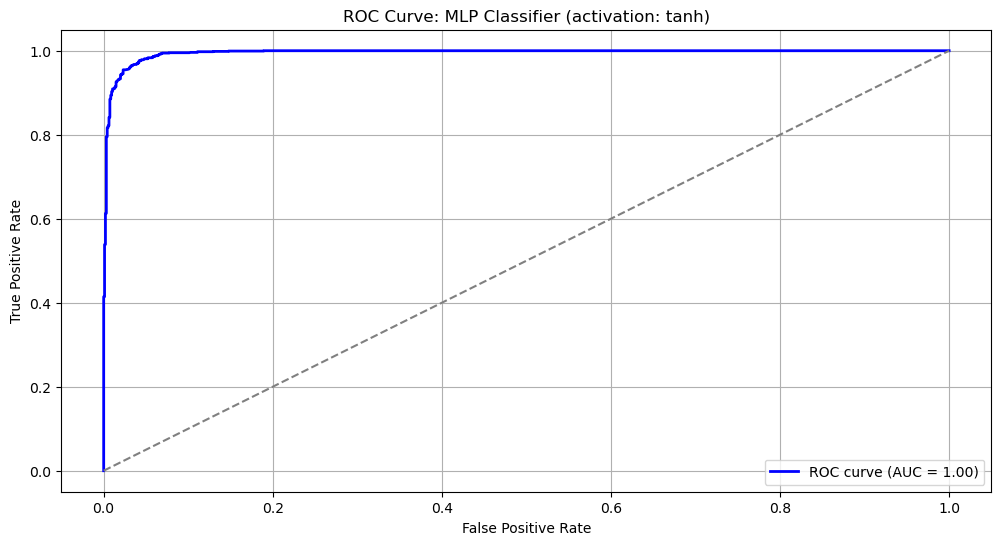

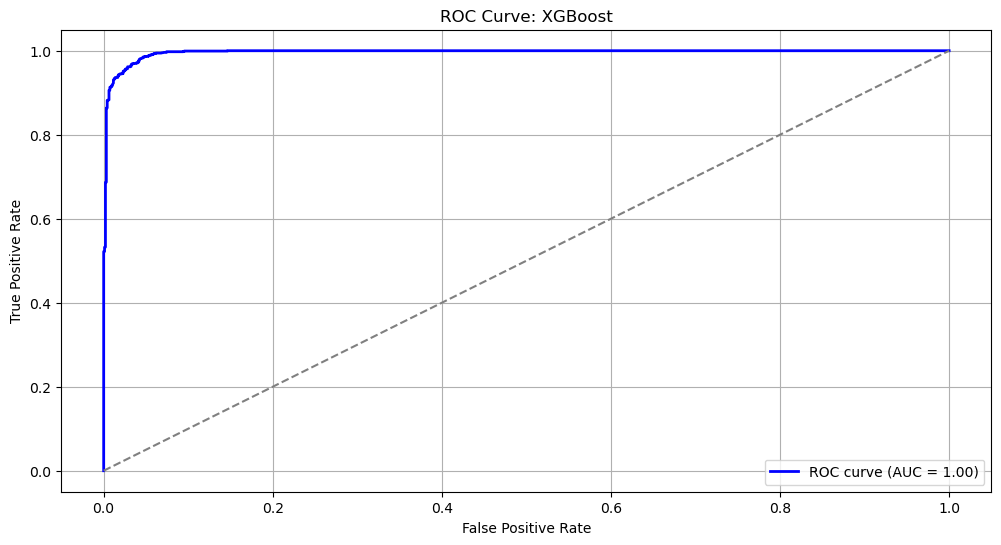

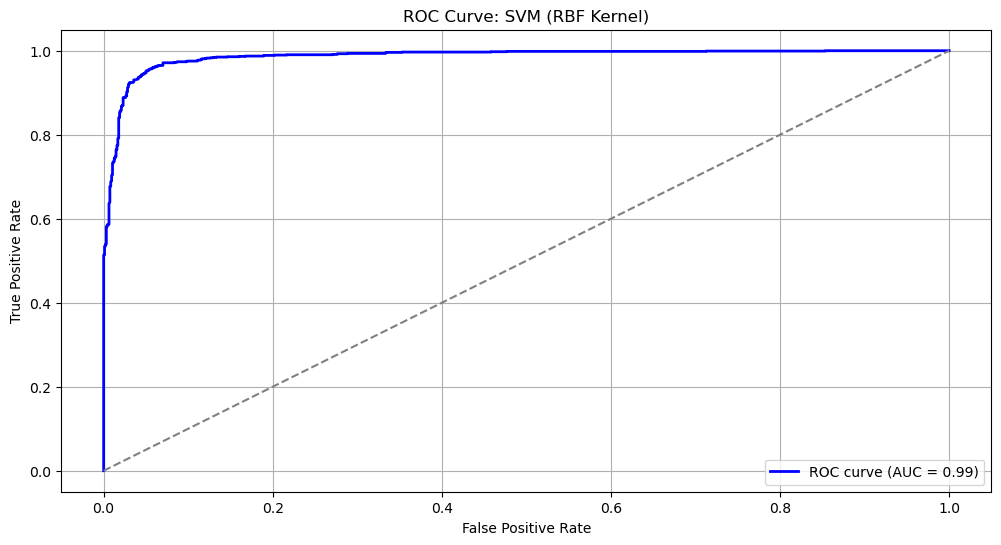

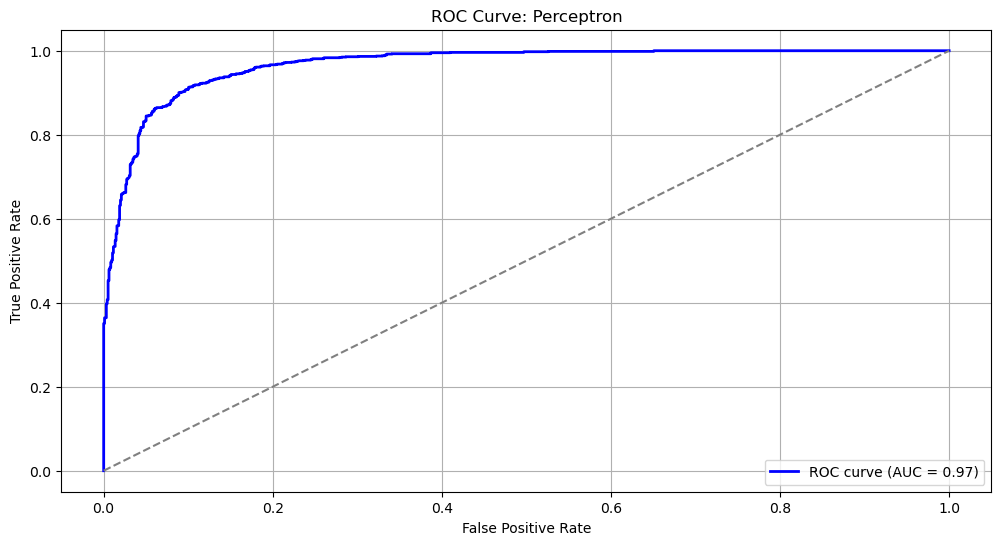

In [127]:
from sklearn.metrics import roc_curve, auc, roc_auc_score

# Function to plot ROC Curve
def plot_roc_curve(y_test, y_score, model_name):
    plt.figure(figsize=(12, 6))

    # ROC Curve
    fpr, tpr, _ = roc_curve(y_test, y_score)
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, color='blue', lw=2, label=f'ROC curve (AUC = {roc_auc:.2f})')
    plt.plot([0, 1], [0, 1], color='gray', linestyle='--')
    plt.title(f'ROC Curve: {model_name}')
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.legend(loc="lower right")
    plt.grid()
    plt.show()

# Example for MLP Classifier
best_final_mlp = MLPClassifier(hidden_layer_sizes=(64,), activation='tanh', solver='adam', max_iter=1000, random_state=42)
best_final_mlp.fit(X_train_mlp_scaled, y_train_mlp)

# Predicting probabilities for ROC curve regarding the MLP model
y_prob_mlp = best_final_mlp.predict_proba(X_test_mlp_scaled)[:, 1]
plot_roc_curve(y_test_mlp, y_prob_mlp, 'MLP Classifier (activation: tanh)')

# Example for XGBoost Classifier
xgb.fit(X_train22, y_train22)
y_prob_xgb = xgb.predict_proba(X_test22)[:, 1]   # Predict probabilities for ROC curve regarding the XGBoost model
plot_roc_curve(y_test22, y_prob_xgb, 'XGBoost')

# Example for SVM Classifier
svm_model_rbf.fit(X_train_SVM, y_train_SVM)
y_score_svm = svm_model_rbf.decision_function(X_test_SVM)  # Predict scores for ROC curve regarding the SVM model
plot_roc_curve(y_test_SVM, y_score_svm, 'SVM (RBF Kernel)')

# Example for Perceptron Classifier
perceptron_model.fit(X_train_perceptron, y_train_perceptron)
y_score_perceptron = perceptron_model.decision_function(X_test_perceptron)  # Predict scores for ROC curve regarding the Perceptron model
plot_roc_curve(y_test_perceptron, y_score_perceptron, 'Perceptron')


#### **Plotting the combined ROC for multiple classification models**

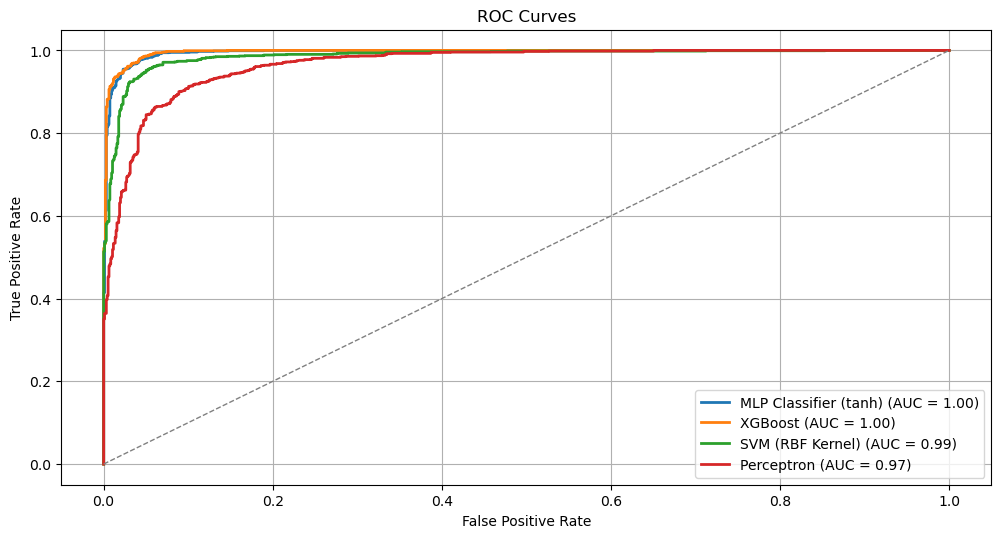

In [128]:
from sklearn.metrics import roc_curve, auc, precision_recall_curve

# Function to plot combined ROC for multiple models
def plot_combined_roc_pr_curves(models, y_tests, y_scores):
    """
    Plots ROC and Precision-Recall curves for multiple models in a single figure.
    
    Args:
        models (list): List of model names.
        y_tests (list): List of true labels for the test sets.
        y_scores (list): List of predicted probabilities or decision scores for the test sets.
    """
    plt.figure(figsize=(12, 13))
    
    # ROC Curves
    plt.subplot(2, 1, 1)
    for model_name, y_test, y_score in zip(models, y_tests, y_scores):
        fpr, tpr, _ = roc_curve(y_test, y_score)
        roc_auc = auc(fpr, tpr)
        plt.plot(fpr, tpr, lw=2, label=f'{model_name} (AUC = {roc_auc:.2f})')
    plt.plot([0, 1], [0, 1], color='gray', linestyle='--', lw=1)  # Diagonal line for reference
    plt.title('ROC Curves')
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.legend(loc="lower right")
    plt.grid()

# Models and their scores
models = ['MLP Classifier (tanh)', 'XGBoost', 'SVM (RBF Kernel)', 'Perceptron']
y_tests = [y_test_mlp, y_test22, y_test_SVM, y_test_perceptron]
y_scores = [
    best_final_mlp.predict_proba(X_test_mlp_scaled)[:, 1],  # MLP probabilities
    xgb.predict_proba(X_test22)[:, 1],                     # XGBoost probabilities
    svm_model_rbf.decision_function(X_test_SVM),           # SVM decision scores
    perceptron_model.decision_function(X_test_perceptron)  # Perceptron decision scores
]

# Plotting the combined ROC and PR curves for better comparison
plot_combined_roc_pr_curves(models, y_tests, y_scores)


#### **Checking for Overfitting**

We can compare the performance of our models on the training set and test set. 

> Overfitting occurs if the model performs significantly better on the training set than on the test set. If there's a large gap between training and test accuracy, the model might be overfitting.



In [129]:
# Training accuracy for MLP Classifier
train_accuracy = best_final_mlp.score(X_train_mlp_scaled, y_train_mlp)
print(f"Training Accuracy (MLP): {train_accuracy:.4f}")

# Test accuracy for MLP Classifier
test_accuracy = best_final_mlp.score(X_test_mlp_scaled, y_test_mlp)
print(f"Test Accuracy (MLP): {test_accuracy:.4f}")

# Training accuracy for XGBoost
train_accuracy_xgb = xgb.score(X_train22, y_train22)
print(f"\nTraining Accuracy (XGBoost): {train_accuracy_xgb:.4f}")

# Test accuracy for XGBoost
test_accuracy_xgb = xgb.score(X_test22, y_test22)
print(f"Test Accuracy (XGBoost): {test_accuracy_xgb:.4f}")

# Training accuracy for SVM
train_accuracy_svm = svm_model_rbf.score(X_train_SVM, y_train_SVM)
print(f"\nTraining Accuracy (SVM): {train_accuracy_svm:.4f}")

# Test accuracy for SVM
test_accuracy_svm = svm_model_rbf.score(X_test_SVM, y_test_SVM)
print(f"Test Accuracy (SVM): {test_accuracy_svm:.4f}")

# Training accuracy for Perceptron
train_accuracy_perceptron = perceptron_model.score(X_train_perceptron, y_train_perceptron)
print(f"\nTraining Accuracy (Perceptron): {train_accuracy_perceptron:.4f}")

# Test accuracy for Perceptron
test_accuracy_perceptron = perceptron_model.score(X_test_perceptron, y_test_perceptron) 
print(f"Test Accuracy (Perceptron): {test_accuracy_perceptron:.4f}")

training_and_test_results_for_all_models = pd.DataFrame({ 'Model': ['MLP', 'XGBoost', 'SVM', 'Perceptron'], 
                            'Training Accuracy': [train_accuracy, train_accuracy_xgb, train_accuracy_svm, train_accuracy_perceptron],
                            'Test Accuracy': [test_accuracy, test_accuracy_xgb, test_accuracy_svm, test_accuracy_perceptron]})

print("---------------------------------------------")
print("\n• Training and Test Results for All Models (based on Test and Training Accuracy):")
training_and_test_results_for_all_models.sort_values(by=['Test Accuracy', 'Training Accuracy'], ascending=False)



Training Accuracy (MLP): 0.9898
Test Accuracy (MLP): 0.9679

Training Accuracy (XGBoost): 0.9889
Test Accuracy (XGBoost): 0.9706

Training Accuracy (SVM): 0.9596
Test Accuracy (SVM): 0.9525

Training Accuracy (Perceptron): 0.9075
Test Accuracy (Perceptron): 0.9068
---------------------------------------------

• Training and Test Results for All Models (based on Test and Training Accuracy):


,Model,Training Accuracy,Test Accuracy
1,XGBoost,0.988919,0.970602
0,MLP,0.989824,0.967888
2,SVM,0.959634,0.952510
3,Perceptron,0.907508,0.906829


The results are sorted first by the values of 'Test Accuracy' and then 'Training Accuracy'

For the above comparison, it is clear that the XGBoost Classifier works well with this dataset whilst the MLP follows with very close results. 
